In [1]:
import uproot
import awkward as ak
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

import sys
sys.path.append("/home/xzcqsfhu/lundtoptagger/")
from plotting.utils_plots_matplotlib import hist_with_errors
from tools.GNN_model_weight.utils_newdata import JSD

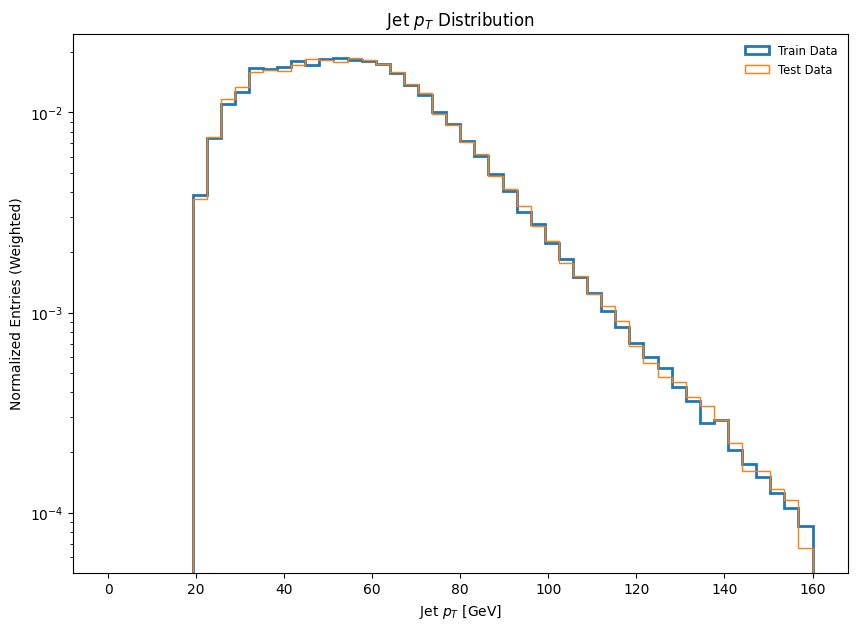

In [2]:
tree_name = "FlatSubstructureJetTree"
train_file_paths = ["/home/xzcqsfhu/lundtoptagger/qg_analysis_data/jet2m_ParT/data_0_160GeV_3.2_4.5_eta/part3_20percent/data_dijet_ParT_batch*_ln_kT_cut_None.root"]
test_file_paths = ["/home/xzcqsfhu/lundtoptagger/qg_analysis_data/jet2m_ParT/data_0_160GeV_3.2_4.5_eta/part1_5percent/data_dijet_ParT_batch*_ln_kT_cut_None.root"]


train_files_paths_with_trees = [f"{path}:{tree_name}" for path in train_file_paths]
test_files_paths_with_trees = [f"{path}:{tree_name}" for path in test_file_paths]
train_data = uproot.concatenate(train_files_paths_with_trees)
test_data = uproot.concatenate(test_files_paths_with_trees)

dsid_weight_map = {    
    364700: 1.0,               
    364701: 1.0,               
    364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
    364703: 26452000.0   * 0.011653  / 24.124114769654568,
    364704: 254610.0 * 0.013358 / 0.6689032716609136,
    364705: 4553.5   * 0.014513 / 0.021711071504255608, 
    364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
    364707: 16.214 * 0.011092 / 7.647190915207464e-05,
    364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
    364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
    364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
    364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
    364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803
    
}

train_weights = np.array([dsid_weight_map[dsid] for dsid in train_data["EventInfo_mcChannelNumber"]]) * train_data["EventInfo_mcEventWeight"]
test_weights = np.array([dsid_weight_map[dsid] for dsid in test_data["EventInfo_mcChannelNumber"]]) * test_data["EventInfo_mcEventWeight"]

plt.figure(figsize=(10, 7), dpi=100)
plt.hist(train_data["fjet_pt"], weights=train_weights, bins=50, range=(0,160), density=True, linewidth=2, label="Train Data", histtype="step")
plt.hist(test_data["fjet_pt"], weights=test_weights, bins=50, range=(0,160), density=True, linewidth=1, label="Test Data", histtype="step")
plt.xlabel("Jet $p_{T}$ [GeV]")
plt.ylabel("Normalized Entries (Weighted)")
plt.title("Jet $p_{T}$ Distribution")
plt.yscale("log")
plt.legend(loc='upper right', frameon=False, fontsize='small')

In [3]:
score_files_paths = [
    "/home/xzcqsfhu/lundtoptagger/qg_analysis_data/jet2m_ParT/scores/hollistic_scoring/0_160_pt_3.2_4.5_50%train_20%test/Final_Scores_ParT_20%_test_fwd_lowpt_kTNone.root"
]

json_file = [
    "/home/xzcqsfhu/lundtoptagger/meta.json"
]

tree_name = "FlatSubstructureJetTree"

In [4]:
import json

# Load metadata from the json file specified in the previous cell
with open(json_file[0], 'r') as f:
    meta_data = json.load(f)

dsid_numerators = {}

if "by_dsid" in meta_data:
    for dsid, values_list in meta_data["by_dsid"].items():
        if isinstance(values_list, list) and len(values_list) > 0:
            values = values_list[0]
            
            xsec = values.get('cross_section_pb', values.get('xsec'))
            genfilteff = values.get('genFiltEff', values.get('genfilteff'))
            kfactor = values.get('kfactor', 1.0)
            
            if xsec is not None and genfilteff is not None:
                # Store numerator = xsec * genfilteff * kfactor
                # sum_of_weight is not in JSON, will be calculated from data
                dsid_numerators[int(dsid)] = xsec * genfilteff * kfactor
            else:
                 print(f"Warning: Missing required values for dsid {dsid}. Found keys: {list(values.keys())}")
else:
    print("Error: 'by_dsid' key not found in JSON data")

print(f"Created dsid_numerators with {len(dsid_numerators)} entries")

Created dsid_numerators with 13 entries


In [5]:
# dsid_weight_map = {    
#     # 364700: , 78050000000.0 * 0.9753257 / 
#     # 364701: , # To be calculated
#     364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
#     364703: 26452000.0   * 0.011653  / 24.124114769654568,
#     364704: 254610.0 * 0.013358 / 0.6689032716609136,
#     364705: 4553.5   * 0.014513 / 0.021711071504255608, 
#     364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
#     364707: 16.214 * 0.011092 / 7.647190915207464e-05,
#     364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
#     364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
#     364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
#     364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
#     364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
#     426345: 950.41935,
#     801471: 0.0189,
#     801859: 12.45803
# }
# for key, val in dsid_weight_map.items():
#     print(f"key: {key}, val: {val}")

# Manual dsid_weight_map commented out to use the one calculated from the json file above
# dsid_weight_map = {
#     364703: 12823.94988,
#     364704: 5081.45927,
#     364705: 3017.75098,
#     364706: 4371.00012,
#     364707: 2349.98631,
#     426345: 950.41935,
#     801471: 0.0189,
#     801859: 12.45803,
#     801661: 1.0,
#     364702: 1.0,

#     364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
#     364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
#     364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
#     364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
#     364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
# }

In [6]:
score_files_paths_with_trees = [f"{path}:{tree_name}" for path in score_files_paths]
data = uproot.concatenate(score_files_paths_with_trees)

In [7]:
# This give the same output as just entering the variable name in a notebook cell
from IPython.display import display
display(data.fields)

['fjet_m',
 'fjet_pt',
 'fjet_eta',
 'fjet_phi',
 'fjet_truth_label',
 'fjet_Nconst',
 'fjet_Nconst_Charged',
 'parT_score',
 'EventInfo_mcEventWeight',
 'EventInfo_mcChannelNumber',
 'labels',
 'fjet_LundNet_SRJ_eta3.2_4.5_pt0_160_50%_batch4500_lr0.0004_e18_score',
 'fjet_LundNet_SRJ_eta45_pt0_1300_1%_batch4500_lr0.0004_e26_score']

In [8]:
print("Signal jets:", np.sum(data["labels"]==1))
print("Background jets:", np.sum(data["labels"]==0))
print("Total:", len(data))

Signal jets: 168634
Background jets: 479523
Total: 648157


In [9]:
# Weight = mceventweight * xsec * genfilteff * kfactor / sum_of_weight
# Per instructions: Using weight map based ONLY on numerators (effectively assuming sum_of_weights = 1)

mc_channel_number = ak.to_numpy(data["EventInfo_mcChannelNumber"])
mc_event_weight = ak.to_numpy(data["EventInfo_mcEventWeight"])
unique_dsids = np.unique(mc_channel_number)

# 1. Determine weight factors per DSID
dsid_factors = {}

for dsid in unique_dsids:
    # Just use the numerator: xsec * genfilteff * kfactor
    dsid_factors[int(dsid)] = dsid_numerators.get(int(dsid), 0.0)

# 2. Apply weights
# Initialize weights array
weights = np.zeros_like(mc_event_weight)

# Apply factor for each DSID
for dsid, factor in dsid_factors.items():
    mask = (mc_channel_number == dsid)
    weights[mask] = factor * mc_event_weight[mask]

print(f"Calculated weights for {len(weights)} events using only numerators.")
print(f"Mean weight: {np.mean(weights)}")
print(weights[:20])

Calculated weights for 648157 events using only numerators.
Mean weight: 18885747721.587
[7.61241709e+10 7.61241709e+10 7.61241709e+10 7.61241709e+10
 7.61241709e+10 7.61241709e+10 7.61241709e+10 7.61241709e+10
 7.61241709e+10 7.61241709e+10 7.61241709e+10 7.61241709e+10
 7.61241709e+10 7.61241709e+10 7.61241709e+10 7.61241709e+10
 7.61241709e+10 7.61241709e+10 7.61241709e+10 7.61241709e+10]


In [10]:
dsid_weight_map = {    
    364700: 1.0,               
    364701: 1.0,               
    364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
    364703: 26452000.0   * 0.011653  / 24.124114769654568,
    364704: 254610.0 * 0.013358 / 0.6689032716609136,
    364705: 4553.5   * 0.014513 / 0.021711071504255608, 
    364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
    364707: 16.214 * 0.011092 / 7.647190915207464e-05,
    364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
    364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
    364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
    364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
    364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803
    
}

In [11]:
# Weight = mceventweight * xsec * genfilteff * kfactor / sum_of_weight
# dsid_weight_map contains the pre-calculated factor (xsec * genfilteff * kfactor / sum_of_weight)
weights = np.array([dsid_weight_map[dsid] for dsid in data["EventInfo_mcChannelNumber"]]) * data["EventInfo_mcEventWeight"]

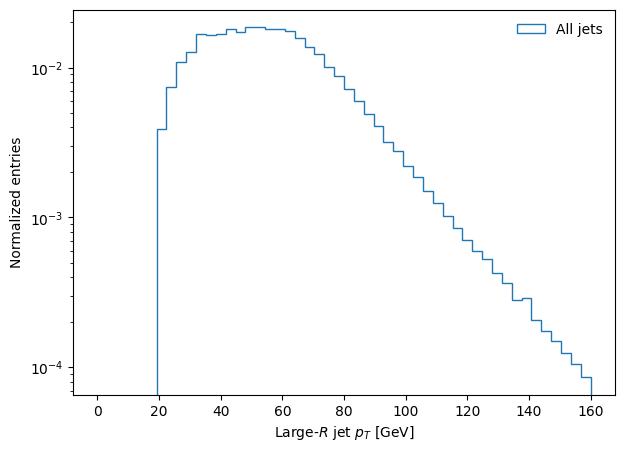

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5), dpi=100)
plt.hist(data["fjet_pt"], weights=weights, bins=50, range=(0, 160), density=True, histtype="step", label="All jets")
plt.xlabel(r"Large-$R$ jet $p_T$ [GeV]")
plt.ylabel("Normalized entries")
plt.yscale("log")
plt.legend(frameon=False)
plt.show()

In [13]:
def calc_best_discriminant(truth_labels, pqcd, phbb, phcc, ptop, step=0.01):
    # TODO: generalise to arbitrary number of classes
    values = np.arange(step, 1.0, step)
    xx, yy = np.meshgrid(values, values)
    mask = xx + yy < 1

    best_auc = 0
    for fhbb, fhcc in tqdm(np.stack([xx[mask], yy[mask]], axis=-1)):
        denoms = fhbb * phbb + fhcc * phcc + (1 - fhbb - fhcc) * pqcd
        scores = np.log(ptop / denoms)
        auc = roc_auc_score(truth_labels, scores)

        # TODO: is finding the best AUC the right thing to do?
        # TODO: does the ROC curve calculation work correctly if the scores are not normalized to (0,1)?
        # (important for this function and also for the plots later on)
        # TODO: Should use data weights in this calculation!
        if auc > best_auc:
            best_auc = auc
            best_fhbb, best_fhcc = fhbb, fhcc

    return best_auc, best_fhbb, best_fhcc

In [14]:
do_calc_best_discriminant = False
if do_calc_best_discriminant:
    GN3X_best_auc, best_fhbb, best_fhcc = calc_best_discriminant(
        data["labels"],
        data["GN3X_pqcd"],
        data["GN3X_phbb"],
        data["GN3X_phcc"],
        data["GN3X_ptop"],
        step=0.01
    )
    print(f"GN3X best AUC: {GN3X_best_auc:.4f}, fhbb: {best_fhbb:.4f}, fhcc: {best_fhcc:.4f}")
# GN3X best AUC: 0.9349, fhbb: 0.0100, fhcc: 0.0400

In [15]:
if do_calc_best_discriminant:
    fhbb = best_fhbb
    fhcc = best_fhcc
else:
    fhbb = 0.05
    fhcc = 0.05

try:
    if "GN3X_pqcd" in data.fields:
        pqcd = data["GN3X_pqcd"]
    else:
        # Calculate pqcd as sum of components if not present
        pqcd = data["GN3X_pqcdbb"] + data["GN3X_pqcdbx"] + data["GN3X_pqcdcx"] + data["GN3X_pqcdll"]

    denoms = fhbb * data["GN3X_phbb"] + fhcc * data["GN3X_phcc"] + (1 - fhbb - fhcc) * pqcd
    gn3x_scores = np.log(data["GN3X_ptop"] / denoms)
except Exception as e:
    print(f"Error calculating GN3X scores: {e}")
    gn3x_scores = None

Error calculating GN3X scores: no field 'GN3X_pqcdbb' in record with 13 fields


In [16]:
models = {
    # Specialist Model (trained on 20% data for this specific forward region)
    "LundNet 3.2-4.5 eta 0-160 pT 20%": {
        "scores": data["fjet_LundNet_SRJ_eta3.2_4.5_pt0_160_50%_batch4500_lr0.0004_e18_score"]
    },
    
    # Holistic Model (The global benchmark)
    "LundNet 1% (Baseline)": {
        "scores": data["fjet_LundNet_SRJ_eta45_pt0_1300_1%_batch4500_lr0.0004_e26_score"]
    },
    
    # Baseline Comparison
    "ParT (Baseline)": {
        "scores": data["parT_score"]
    }
}

# Set tick format for all plots
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams["axes.formatter.use_mathtext"] = True

# Increase tick mark size
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3

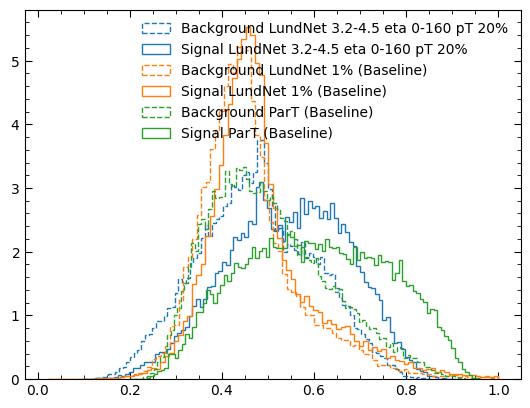

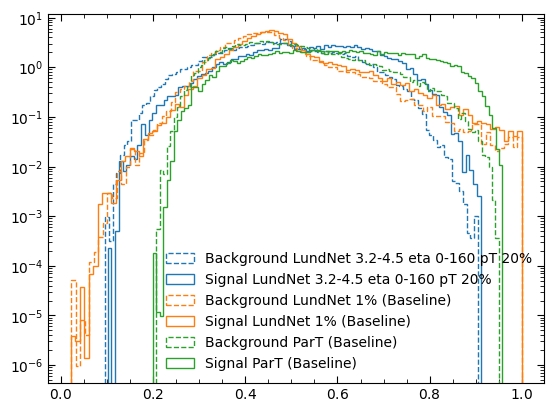

In [17]:
# Extract scores and labels
labels = data["labels"]

hist_params = dict(
    bins = 100,
    # range = (0, 1),
    density = True,
    # alpha = 0.5,
    histtype = "step"
)

selected_models = ["LundNet 3.2-4.5 eta 0-160 pT 20%", "LundNet 1% (Baseline)", "ParT (Baseline)"]
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
    plt.yscale('log')
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

#selected_models = ["GN3X"]
#for i, model in enumerate(selected_models):
#    scores = models[model]["scores"]
#    hist_params["color"] = f"C{i}"
#    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
#    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
#plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
#plt.show()
# for i, model in enumerate(selected_models):
#     scores = models[model]["scores"]
#     hist_params["color"] = f"C{i}"
#     plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
#     plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
#     plt.yscale('log')
# plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

In [18]:
# TODO: working point should be calculated differently if weights are used - sum of weights of signal jets with score above threshold should be 50% of total weight of signal jets
# it doesn't make a difference for currently used signal samples because their MC weights are all equal to 1, but this is something to keep in mind for future samples
for model in models:
    # Sort scores corresponding to signal jets
    scores = models[model]["scores"]
    if scores is None:
        print(f"Skipping {model} because scores are None")
        continue

    signal_scores = scores[labels == 1]
    sorted_signal_scores = np.sort(signal_scores)

    # Determine the threshold for 50% signal efficiency
    signal_efficiency = 0.5
    threshold_index = int(signal_efficiency * len(sorted_signal_scores))
    threshold_score = sorted_signal_scores[threshold_index]

    models[model]["threshold_score"] = threshold_score
    print(f"50% signal efficiency threshold for {model}:", threshold_score)

50% signal efficiency threshold for LundNet 3.2-4.5 eta 0-160 pT 20%: 0.5385538935661316
50% signal efficiency threshold for LundNet 1% (Baseline): 0.4779769480228424
50% signal efficiency threshold for ParT (Baseline): 0.6137844


In [19]:
var_params = {
    "fjet_m":  {"title": "Large-$R$ jet mass [GeV]",  "bins": 45, "range": (50, 500) },
    "fjet_pt": {"title": "Large-$R$ jet $p_T$ [GeV]", "bins": 30, "range": (0, 3000)},
}

In [20]:
# selected_models = models.keys()  # Use all models for now
# selection = (data["fjet_pt"] > 350) & (np.abs(data["fjet_eta"] < 2))
# plot_signal_after_tagging = False
# plot_errorbars = True
# calc_jsd = False

# plot_params = {
#     "lin": {
#         "yscale": "linear",
#         "ylim": (0, 0.06),
#     },
#     "log": {
#         "yscale": "log",
#         "ylim": (1e-5, 10),
#     }
# }

# for params in plot_params.values():
#     for var in var_params:
#         fig, ax = plt.subplots(figsize=(6.6, 6.6), dpi=200)

#         var_data = data[var]
#         hist_params = dict(
#             bins = var_params[var]["bins"],
#             range = var_params[var]["range"],
#             density = True,
#         )

#         # QCD background: shaded dark gray with black outline
#         bkg_counts = plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], label="QCD background", color="dimgray", alpha=0.7, **hist_params)[0]
#         plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], histtype="step", color="black", linewidth=1.2, **hist_params)
#         # Signal: fill with neutral, light colour
#         plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], label="Signal", color="lightsteelblue", alpha=0.6, **hist_params)
#         plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], histtype="step", color="slategray", linewidth=1.2, **hist_params)

#         for i, model in enumerate(selected_models):
#             tagged_as_signal = models[model]["scores"] > models[model]["threshold_score"]

#             if i !=0 and calc_jsd:
#                 bkg_counts_tagged = np.histogram(
#                     ak.to_numpy(var_data[(labels==0) & tagged_as_signal & selection]),
#                     weights=ak.to_numpy(weights[(labels==0) & tagged_as_signal & selection]),
#                     **hist_params
#                 )[0]
#                 JSD_value = JSD(bkg_counts, bkg_counts_tagged)*100  # TODO: maybe shouldn't be expressed as a percentage
#                 JSD_label = f", JSD = {JSD_value:.2f}%"
#             else:
#                 JSD_label = ""

#             if plot_errorbars:
#                 extra_args = dict(fmt='.')
#                 hist_plot_func = hist_with_errors
#             else:
#                 extra_args = dict(histtype="step", linestyle='-' if i==0 else '--', linewidth=1.5)
#                 hist_plot_func = plt.hist
#             hist_plot_func(
#                 var_data[(labels==0) & tagged_as_signal & selection],
#                 weights=weights[(labels==0) & tagged_as_signal & selection],
#                 label=f"QCD tagged as signal{JSD_label}\n({model})",
#                 **hist_params, **extra_args
#             )
#             if plot_signal_after_tagging:
#                 hist_plot_func(
#                     var_data[(labels==1) & tagged_as_signal & selection],
#                     weights=weights[(labels==1) & tagged_as_signal & selection],
#                     label=f"Signal tagged as signal{JSD_label}\n({model})",
#                     **hist_params, **extra_args
#                 )

#         # Add ATLAS label
#         atlas_label = r"ATLAS"
#         atlas_sim = r"Simulation Internal"
#         atlas_info = r"$\sqrt{s} = 13$ TeV, $top$ tagging"  # TODO: make it autimatically use W or top based on selected config
#         jet_info = r"anti-$k_t$ $R=1.0$ UFO Soft-Drop CS+SK jets"
#         selection_info = r"$\epsilon^{\mathrm{rel}}_{\mathrm{sig}}=50\%,\ p_T > 350$ GeV, $| \eta | < 2.0$" # TODO: make this dynamic based on selection, and for the pT plot show the mass cut
#         text_args = {"transform": ax.transAxes, "va": 'top'}
#         ax.text(0.04, 0.97, atlas_label,    fontsize=12, **text_args, fontweight='bold', style='italic')
#         ax.text(0.20, 0.97, atlas_sim,      fontsize=12, **text_args)
#         ax.text(0.04, 0.92, atlas_info,     fontsize=11, **text_args)
#         ax.text(0.04, 0.87, jet_info,       fontsize=11, **text_args)
#         ax.text(0.04, 0.82, selection_info, fontsize=11, **text_args)

#         plt.xlim(var_params[var]["range"])
#         plt.xlabel(var_params[var]["title"])
#         plt.ylabel("Fraction of jets / 10 GeV")  # TODO: make this dynamic based on bin width, and different for the mass and pT plots
#         plt.yscale(params["yscale"])
#         plt.ylim(params["ylim"])
#         # plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
#         plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.45, 0.75))
#         plt.show()

In [21]:
mass = data["fjet_m"]
pt = data["fjet_pt"]
eta = data["fjet_eta"]

mass_cuts = [
    (0, float('inf')),
]
pt_min = 0
pt_max = 160
eta_min = 3.2
eta_max = 4.5
# eta_max = float('inf')

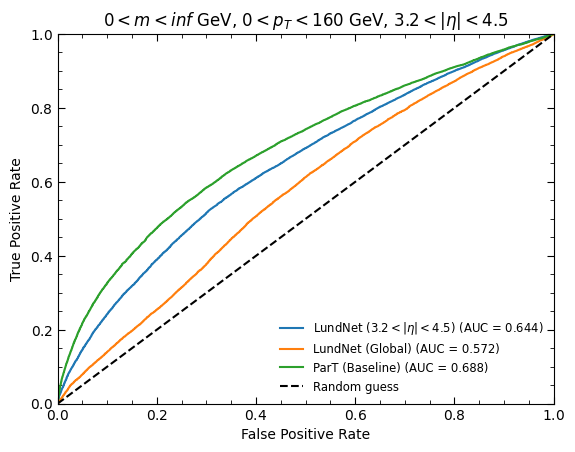

In [22]:
nice_names = {
    "LundNet 3.2-4.5 eta 0-160 pT 20%": r"LundNet ($3.2 < |\eta| < 4.5$)",
    "LundNet 1% (Baseline)":           r"LundNet (Global)",
    "ParT (Baseline)":                 r"ParT (Baseline)"
}

for mass_cut in mass_cuts:
    m_min, m_max = mass_cut
    cuts = (mass > m_min) & (mass < m_max) & (pt > pt_min) & (pt < pt_max) & (np.abs(eta) < eta_max) & (np.abs(eta) > eta_min)
    y_truth_cuts = data["labels"][cuts]
    weights_cuts = weights[cuts]

    for trained_model in models:
        y_pred = models[trained_model]["scores"] if cuts is None else models[trained_model]["scores"][cuts]
        fpr, tpr, thresholds = roc_curve(y_truth_cuts, y_pred, sample_weight=weights_cuts)
        roc_auc = auc(fpr, tpr)

        models[trained_model][f"fpr_{m_min}-{m_max}"] = fpr
        models[trained_model][f"tpr_{m_min}-{m_max}"] = tpr

        # 2. Use the mapping to get the clean name, or default to the key if not found
        display_name = nice_names.get(trained_model, trained_model)
        
        # 3. Format the label with AUC using LaTeX-style formatting
        plt.plot(fpr, tpr, label=fr"{display_name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "--", label="Random guess", color="black")

    # Use LaTeX in titles for a consistent professional look
    plt.title(fr"${m_min} < m < {m_max}$ GeV, ${pt_min} < p_T < {pt_max}$ GeV, ${eta_min} < |\eta| < {eta_max}$")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.legend(loc="lower right", frameon=False, fontsize='small')
    plt.show()

/tmp/ipykernel_158980/4058463355.py:25: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(tpr, 1/fpr, label=display_name, color=f"C{i}")
/tmp/ipykernel_158980/4058463355.py:51: RuntimeWarning: divide by zero encountered in divide
  interp_rej = np.interp(ref_tpr, tpr, 1/fpr, left=np.nan, right=np.nan)
/tmp/ipykernel_158980/4058463355.py:52: RuntimeWarning: divide by zero encountered in divide
  ref_rej = 1/ref_fpr
/tmp/ipykernel_158980/4058463355.py:53: RuntimeWarning: invalid value encountered in divide
  ratio = interp_rej / ref_rej


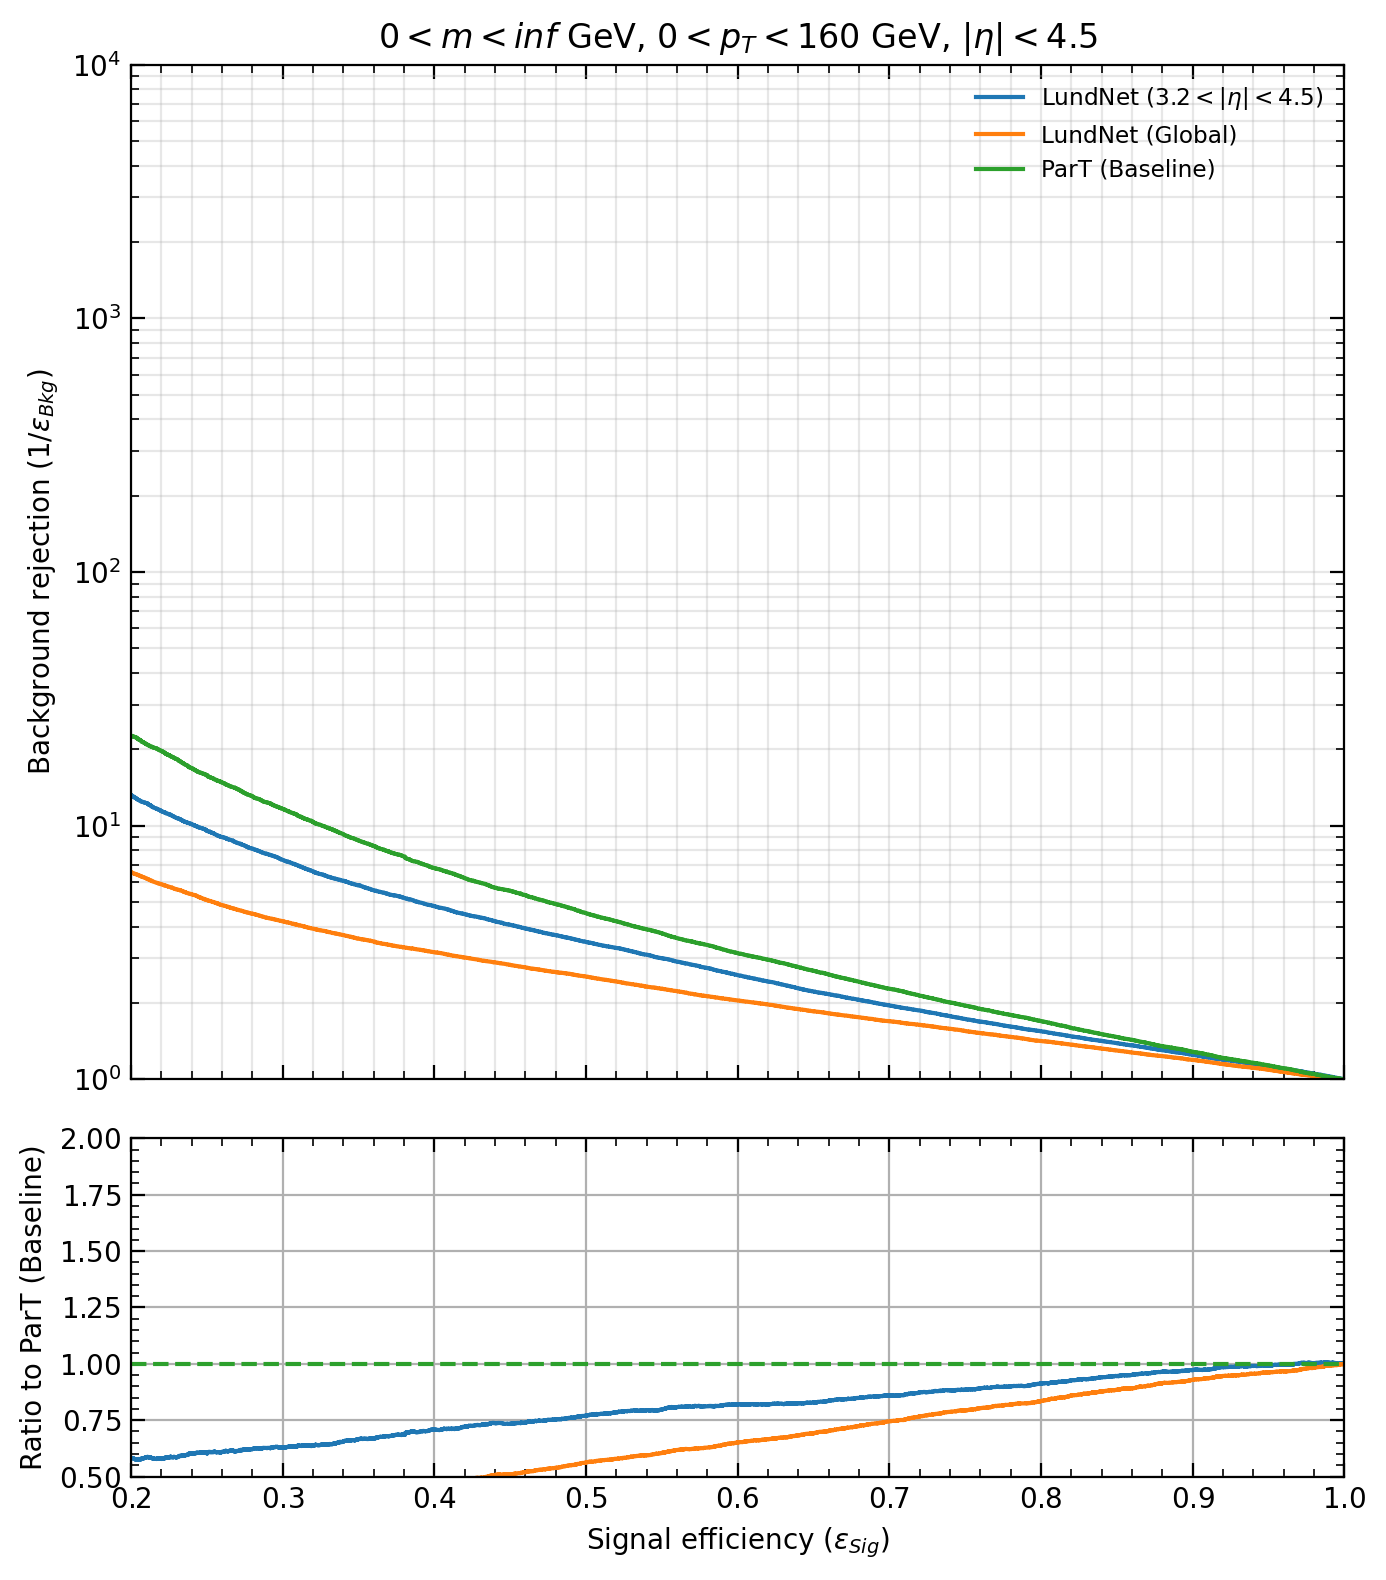

In [23]:
# 1. Update the reference model key to match your current dictionary
reference_model = "ParT (Baseline)"
selected_models = models.keys()

show_grid = True
plot_ratio = True


for mass_cut in mass_cuts:
    m_min, m_max = mass_cut

    if plot_ratio:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True, dpi=200)
    else:
        fig, ax1 = plt.subplots(figsize=(6, 6), dpi=200)

    for i, trained_model in enumerate(selected_models):
        fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
        tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
        
        # Get clean name for legend
        display_name = nice_names.get(trained_model, trained_model)
        
        # Plot Background Rejection (1/FPR)
        ax1.plot(tpr, 1/fpr, label=display_name, color=f"C{i}")

    # Format Main Plot
    ax1.set_title(fr"${m_min} < m < {m_max}$ GeV, ${pt_min} < p_T < {pt_max}$ GeV, $|\eta| < {eta_max}$")
    ax1.set_ylabel("Background rejection ($1/\epsilon_{Bkg}$)")
    ax1.set_xlim([0.2, 1])
    ax1.set_ylim([1, 1e4])
    ax1.set_yscale("log")
    ax1.legend(frameon=False, fontsize='small')
    ax1.grid(show_grid, which='both', alpha=0.3)

    # Ratio subplot
    if plot_ratio:
        ref_fpr = models[reference_model][f"fpr_{m_min}-{m_max}"]
        ref_tpr = models[reference_model][f"tpr_{m_min}-{m_max}"]

        for i, trained_model in enumerate(selected_models):
            color = f"C{i}"
            if trained_model == reference_model:
                ax2.axhline(1, color=color, ls="--")
                continue
                
            fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
            tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
            
            # Interpolate to reference tpr points
            interp_rej = np.interp(ref_tpr, tpr, 1/fpr, left=np.nan, right=np.nan)
            ref_rej = 1/ref_fpr
            ratio = interp_rej / ref_rej
            
            ax2.plot(ref_tpr, ratio, color=color)

        ax2.set_xlabel("Signal efficiency ($\epsilon_{Sig}$)")
        ax2.set_ylabel(f"Ratio to ParT (Baseline)")
        ax2.set_ylim([0.5, 2])
        ax2.grid(show_grid)

    plt.tight_layout()
    plt.show()

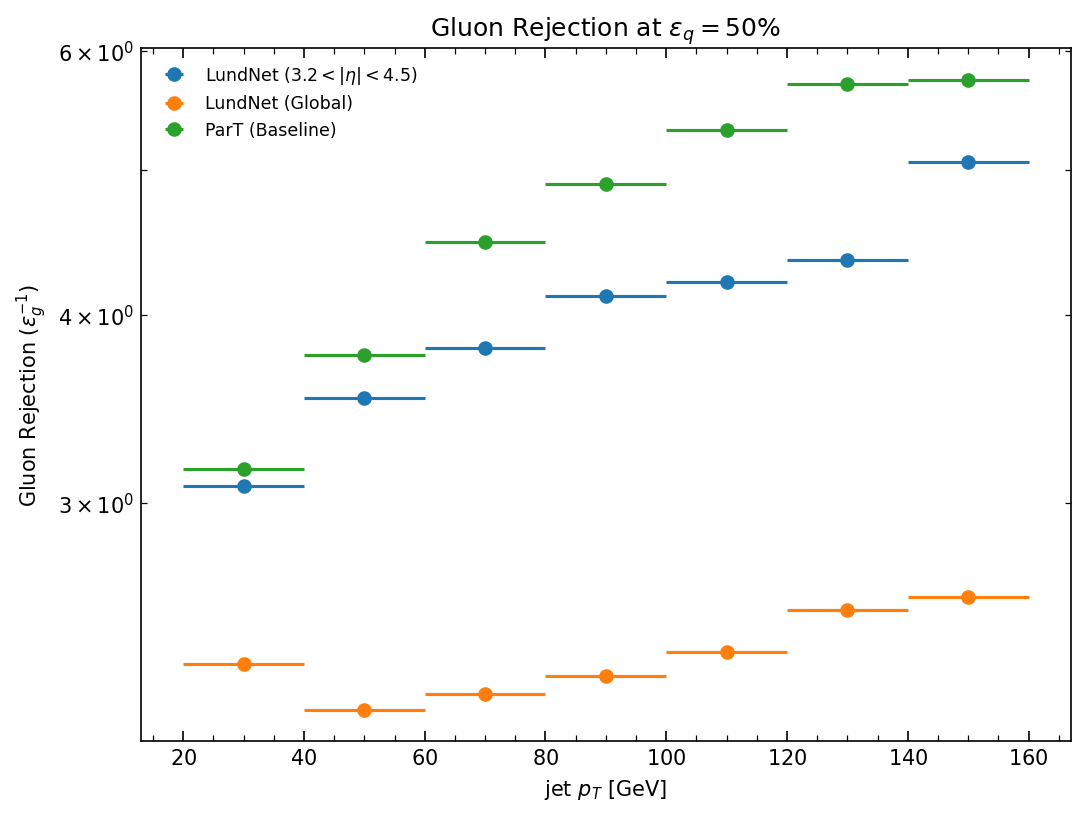

In [24]:
def plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5):
    """
    Graphs the gluon rejection (1/epsilon_g) at a fixed quark efficiency (epsilon_q) 
    as a function of jet pT. Uses 'nice_names' for clean legend labeling.
    """
    pt = data["fjet_pt"]
    labels = data["labels"]
    
    bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
    bin_half_widths = (pt_bins[1:] - pt_bins[:-1]) / 2
    
    plt.figure(figsize=(8, 6), dpi=150)
    
    for model_name in models:
        scores = models[model_name]["scores"]
        rejections = []
        valid_centers = []
        valid_xerr = []
        
        # Pull label from global nice_names defined in earlier cell
        label_name = nice_names.get(model_name, model_name)
        
        for i in range(len(pt_bins)-1):
            p_min, p_max = pt_bins[i], pt_bins[i+1]
            mask = (pt >= p_min) & (pt < p_max)
            
            if np.sum(mask) < 10: continue
            
            y_true = ak.to_numpy(labels[mask])
            y_score = ak.to_numpy(scores[mask])
            w = ak.to_numpy(weights[mask])
            
            if len(np.unique(y_true)) < 2: continue
            
            # Split into signal and background
            sig_mask = (y_true == 1)
            bkg_mask = (y_true == 0)
            
            s_scores = y_score[sig_mask]
            s_weights = w[sig_mask]
            b_scores = y_score[bkg_mask]
            b_weights = w[bkg_mask]
            
            if len(s_scores) == 0 or len(b_scores) == 0: continue
            
            # 1. Determine Threshold from Signal (Weighted)
            sorter = np.argsort(s_scores)
            s_scores_sorted = s_scores[sorter]
            s_weights_sorted = s_weights[sorter]
            
            cum_w = np.cumsum(s_weights_sorted)
            total_s_w = cum_w[-1]
            target_w = total_s_w * (1 - signal_efficiency)
            idx = np.searchsorted(cum_w, target_w)
            threshold = s_scores_sorted[min(idx, len(s_scores_sorted)-1)]
            
            # 2. Calculate Background Efficiency (FPR)
            pass_mask = b_scores > threshold
            W_total = np.sum(b_weights)
            W_pass = np.sum(b_weights[pass_mask])
            
            if W_pass == 0: continue
                
            epsilon_g = W_pass / W_total
            
            # Rejection R = 1 / epsilon
            R = 1.0 / epsilon_g
            
            rejections.append(R)
            valid_centers.append(bin_centers[i])
            valid_xerr.append(bin_half_widths[i])
            
        # Plot with horizontal x-err only (no y-uncertainty)
        plt.errorbar(valid_centers, rejections, xerr=valid_xerr, 
                     fmt='o', label=label_name, capsize=0, elinewidth=1.5)
        
    plt.xlabel(r"jet $p_T$ [GeV]")
    plt.ylabel(r"Gluon Rejection ($\epsilon_{g}^{-1}$)") # Reverted label
    plt.yscale("log") # Removed log scale as requested
    plt.legend(frameon=False, fontsize='small')
    plt.title(r"Gluon Rejection at $\epsilon_{q} = 50\%$")
    plt.show()

# Define pT bins for your current study (e.g., High-pT region)
pt_bins = np.linspace(20, 160, 8)

# Call function
plot_gluon_rejection_vs_pt(
    models, 
    data, 
    weights, 
    pt_bins, 
    signal_efficiency=0.5
)

/tmp/ipykernel_158980/1308484874.py:35: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(tpr, 1/fpr, label=f"{display_name} (AUC = {roc_auc:.4f})", color=color)
/tmp/ipykernel_158980/1308484874.py:35: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(tpr, 1/fpr, label=f"{display_name} (AUC = {roc_auc:.4f})", color=color)
/tmp/ipykernel_158980/1308484874.py:35: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(tpr, 1/fpr, label=f"{display_name} (AUC = {roc_auc:.4f})", color=color)
/tmp/ipykernel_158980/1308484874.py:74: RuntimeWarning: divide by zero encountered in divide
  interp_rej = np.interp(ref_tpr, tpr, 1/fpr, left=np.nan, right=np.nan)
/tmp/ipykernel_158980/1308484874.py:75: RuntimeWarning: divide by zero encountered in divide
  ratio = interp_rej / (1/ref_fpr)
/tmp/ipykernel_158980/1308484874.py:75: RuntimeWarning: invalid value encountered in divide
  ratio = interp_rej / (1/ref_fpr)
/tmp/ipykernel_158980/1308484874.py:85: UserWarning

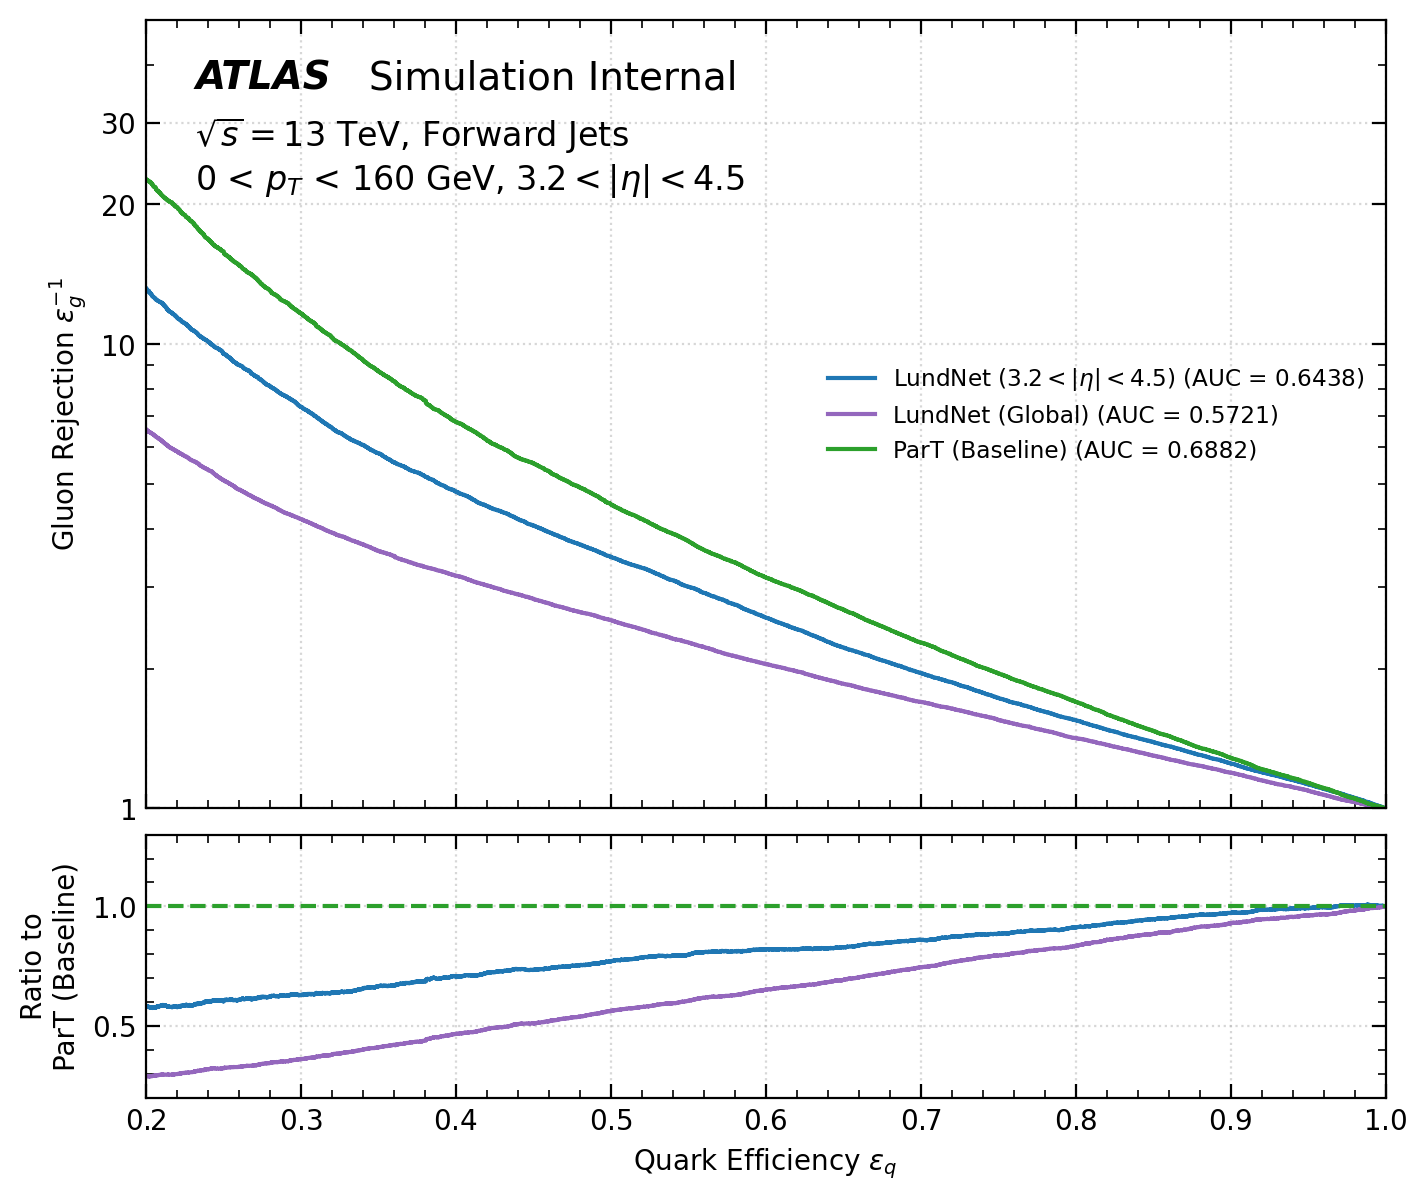

In [25]:
from matplotlib.ticker import MultipleLocator
from sklearn.metrics import auc

# Configuration
reference_model = "ParT (Baseline)"
selected_models = models.keys()
show_grid = True
plot_ratio = True

model_colors = {
    "ParT (Baseline)": "tab:green",
    "LundNet 1% (Baseline)": "tab:purple"
}
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for mass_cut in mass_cuts:
    m_min, m_max = mass_cut

    if plot_ratio:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), 
                                       gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}, 
                                       sharex=True, dpi=200)
    else:
        fig, ax1 = plt.subplots(figsize=(6, 6), dpi=200)

    for i, trained_model in enumerate(selected_models):
        fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
        tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
        roc_auc = auc(fpr, tpr)
        
        display_name = nice_names.get(trained_model, trained_model)
        color = model_colors.get(trained_model, default_colors[i % len(default_colors)])
        
        # Plot Main Rejection
        ax1.plot(tpr, 1/fpr, label=f"{display_name} (AUC = {roc_auc:.4f})", color=color)

    # Format Main Plot
    ax1.set_ylabel(r"Gluon Rejection $\epsilon_g^{-1}$")
    ax1.set_yscale("log")
    ax1.set_xlim([0.2, 1])
    ax1.set_ylim([1, 50])
    ax1.set_yticks([1, 10, 20, 30])
    ax1.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    ax1.legend(frameon=False, fontsize='small', loc='center right')
    
    if show_grid:
        ax1.xaxis.set_major_locator(MultipleLocator(0.1))
        ax1.grid(True, which='major', axis='both', ls=":", alpha=0.5)

    # ATLAS Style Text
    text_args = {"transform": ax1.transAxes, "va": 'top'}
    ax1.text(0.04, 0.95, "ATLAS", fontsize=14, fontweight='bold', style='italic', **text_args)
    ax1.text(0.18, 0.95, "Simulation Internal", fontsize=14, **text_args)
    ax1.text(0.04, 0.88, r"$\sqrt{s} = 13$ TeV, Forward Jets", fontsize=12, **text_args)
    selection_info = fr"{pt_min} < $p_T$ < {pt_max} GeV, $3.2 < |\eta| < 4.5$"
    ax1.text(0.04, 0.82, selection_info, fontsize=12, **text_args)

    # Ratio subplot
    if plot_ratio:
        ref_fpr = models[reference_model][f"fpr_{m_min}-{m_max}"]
        ref_tpr = models[reference_model][f"tpr_{m_min}-{m_max}"]

        for i, trained_model in enumerate(selected_models):
            color = model_colors.get(trained_model, default_colors[i % len(default_colors)])
            
            if trained_model == reference_model:
                ax2.axhline(1, color=color, ls="--")
                continue
                
            fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
            tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
            
            # Interpolate to reference
            interp_rej = np.interp(ref_tpr, tpr, 1/fpr, left=np.nan, right=np.nan)
            ratio = interp_rej / (1/ref_fpr)
            ax2.plot(ref_tpr, ratio, color=color)

        ax2.set_xlabel(r"Quark Efficiency $\epsilon_q$")
        ax2.set_ylabel(f"Ratio to\nParT (Baseline)", fontsize=10)
        ax2.set_ylim([0.2, 1.3])
        if show_grid:
            ax2.xaxis.set_major_locator(MultipleLocator(0.1))
            ax2.grid(True, which='major', axis='both', ls=":", alpha=0.5)

    plt.tight_layout()
    plt.show()

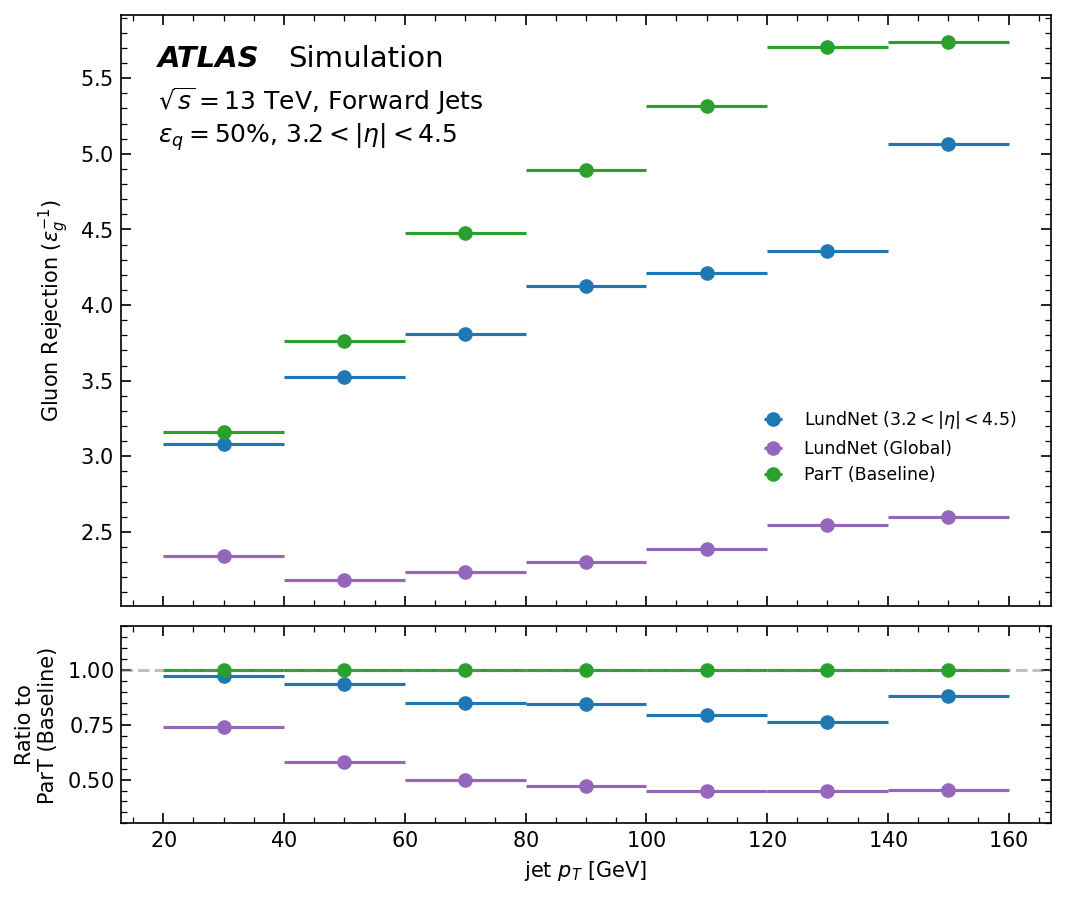

In [26]:
def plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5, reference_model="ParT (Baseline)"):
    pt = data["fjet_pt"]
    labels = data["labels"]
    bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
    bin_half_widths = (pt_bins[1:] - pt_bins[:-1]) / 2
    
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 7), dpi=150, sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    
    model_colors = {"ParT (Baseline)": "tab:green", "LundNet 1% (Baseline)": "tab:purple"}
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    model_rejections = {}
    
    for i, model_name in enumerate(models):
        scores = models[model_name]["scores"]
        rejections = []
        color = model_colors.get(model_name, default_colors[i % len(default_colors)])
        
        for i_bin in range(len(pt_bins)-1):
            mask = (pt >= pt_bins[i_bin]) & (pt < pt_bins[i_bin+1])
            if np.sum(mask) < 10: 
                rejections.append(np.nan); continue
            
            y_true, y_score, w = ak.to_numpy(labels[mask]), ak.to_numpy(scores[mask]), ak.to_numpy(weights[mask])
            
            # Weighted threshold calculation
            s_mask, b_mask = (y_true == 1), (y_true == 0)
            s_scores, s_w = y_score[s_mask], w[s_mask]
            
            sorter = np.argsort(s_scores)
            cum_w = np.cumsum(s_w[sorter])
            threshold = s_scores[sorter][np.searchsorted(cum_w, cum_w[-1] * (1 - signal_efficiency))]
            
            # Rejection
            eps_g = np.sum(w[b_mask & (y_score > threshold)]) / np.sum(w[b_mask])
            rejections.append(1.0 / eps_g if eps_g > 0 else np.nan)
            
        rejections = np.array(rejections)
        model_rejections[model_name] = rejections
        
        # Plot Main
        mask = ~np.isnan(rejections)
        ax0.errorbar(bin_centers[mask], rejections[mask], xerr=bin_half_widths[mask], 
                     fmt='o', label=nice_names.get(model_name, model_name), 
                     capsize=0, elinewidth=1.5, color=color)
        
    # Formatting
    ax0.set_ylabel(r"Gluon Rejection ($\epsilon_{g}^{-1}$)")
    #ax0.set_yscale("log")
    ax0.legend(
        frameon=False, 
        loc='lower right', 
        bbox_to_anchor=(0.98, 0.18), # (x, y) coordinates from 0 to 1
        fontsize='small'
    )
    
    # ATLAS Text
    text_args = {"transform": ax0.transAxes, "va": 'top'}
    ax0.text(0.04, 0.95, "ATLAS", fontsize=14, fontweight='bold', style='italic', **text_args)
    ax0.text(0.18, 0.95, "Simulation", fontsize=14, **text_args)
    ax0.text(0.04, 0.88, r"$\sqrt{s} = 13$ TeV, Forward Jets", fontsize=12, **text_args)
    ax0.text(0.04, 0.82, f"$\epsilon_q = {int(signal_efficiency*100)}\%$, $3.2 < |\eta| < {eta_max}$", fontsize=12, **text_args)

    # Ratio Logic
    if reference_model in model_rejections:
        ref_rej = model_rejections[reference_model]
        for i, model_name in enumerate(models):
            color = model_colors.get(model_name, default_colors[i % len(default_colors)])
            ratio = model_rejections[model_name] / ref_rej
            mask = ~np.isnan(ratio)
            ax1.errorbar(bin_centers[mask], ratio[mask], xerr=bin_half_widths[mask], 
                         fmt='o', capsize=0, elinewidth=1.5, color=color)
    
    ax1.axhline(1, color='gray', linestyle='--', alpha=0.5)
    ax1.set_ylabel(f"Ratio to\nParT (Baseline)", fontsize=10)
    ax1.set_xlabel(r"jet $p_T$ [GeV]")
    ax1.set_ylim(0.3, 1.2)
    plt.show()

# Execution
pt_bins = np.linspace(20, 160, 8)
plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5)

Quark Jets  Correlation: 0.6727
Gluon Jets  Correlation: 0.5418


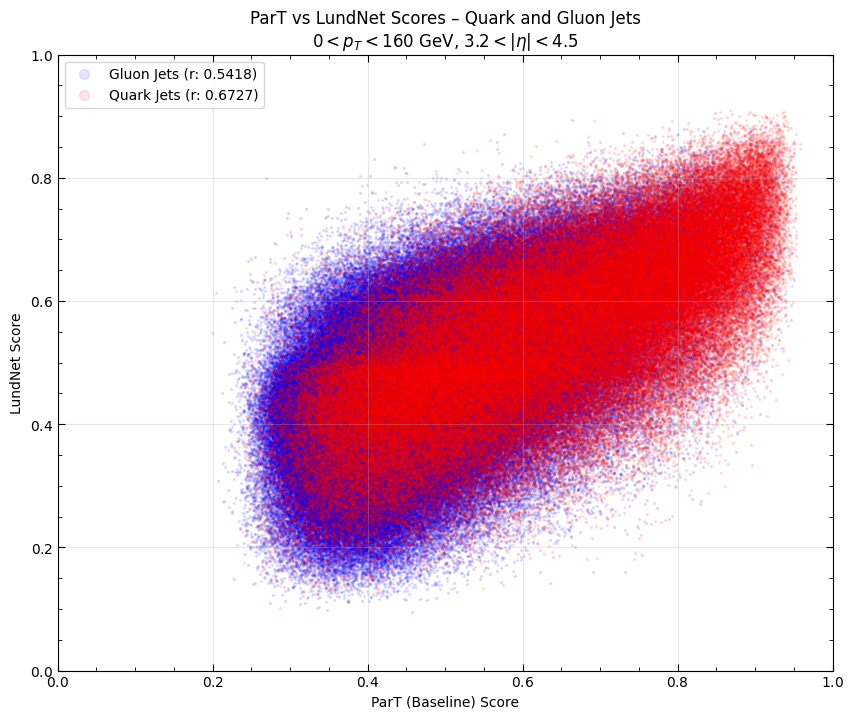

In [27]:
# ── Cell 1: Scatter + 2D density + score difference + profile plot ──────────

mask_sel = np.array(cuts)  # boolean mask from Cell 20/21

part_scores = np.array(models["ParT (Baseline)"]["scores"])[mask_sel]
lund_scores = np.array(models["LundNet 3.2-4.5 eta 0-160 pT 20%"]["scores"])[mask_sel]
labels_sel  = np.array(data["labels"])[mask_sel]

quark_mask  = (labels_sel == 1)
gluon_mask  = (labels_sel == 0)

corr_quark = np.corrcoef(part_scores[quark_mask],  lund_scores[quark_mask])[0, 1]
corr_gluon = np.corrcoef(part_scores[gluon_mask],  lund_scores[gluon_mask])[0, 1]

print(f"Quark Jets  Correlation: {corr_quark:.4f}")
print(f"Gluon Jets  Correlation: {corr_gluon:.4f}")

_pt_text  = f"${pt_min} < p_T < {pt_max}$ GeV"
_eta_text = f"${eta_min} < |\\eta| < {eta_max}$"
_region   = f"{_pt_text}, {_eta_text}"

# --- Scatter plot ---
plt.figure(figsize=(10, 8))
plt.scatter(part_scores[gluon_mask], lund_scores[gluon_mask],
            alpha=0.1, s=2, c='blue', label=f'Gluon Jets (r: {corr_gluon:.4f})')
plt.scatter(part_scores[quark_mask], lund_scores[quark_mask],
            alpha=0.1, s=2, c='red',  label=f'Quark Jets (r: {corr_quark:.4f})')
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel('ParT (Baseline) Score')
plt.ylabel('LundNet Score')
plt.title(f'ParT vs LundNet Scores – Quark and Gluon Jets\n{_region}')
plt.legend(loc='upper left', markerscale=5)
plt.grid(True, alpha=0.3)
plt.show()

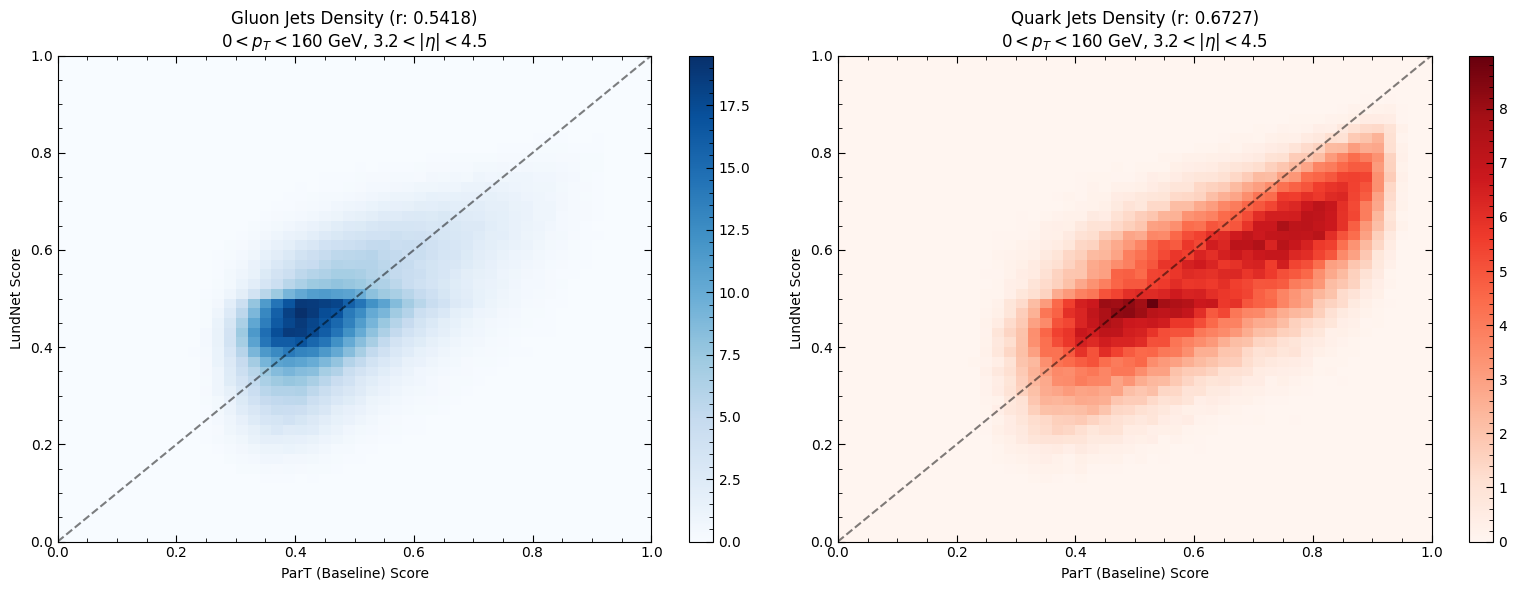

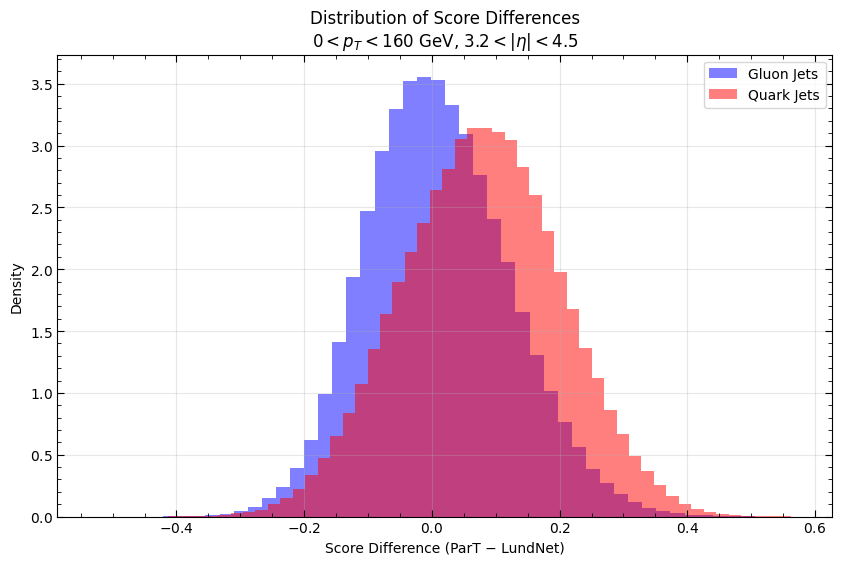

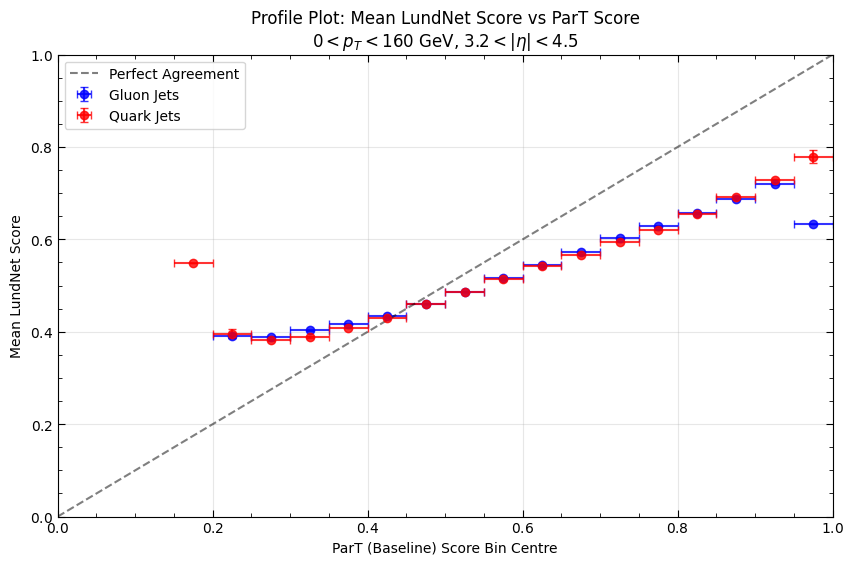

In [28]:

# (all variables from Cell 1 above)

# --- 2a. 2D Histograms ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

h1 = ax1.hist2d(part_scores[gluon_mask], lund_scores[gluon_mask],
                bins=50, cmap='Blues', density=True, range=[[0,1],[0,1]])
ax1.set_title(f'Gluon Jets Density (r: {corr_gluon:.4f})\n{_region}')
ax1.set_xlabel('ParT (Baseline) Score')
ax1.set_ylabel('LundNet Score')
plt.colorbar(h1[3], ax=ax1)
ax1.plot([0,1],[0,1],'k--',alpha=0.5)

h2 = ax2.hist2d(part_scores[quark_mask], lund_scores[quark_mask],
                bins=50, cmap='Reds', density=True, range=[[0,1],[0,1]])
ax2.set_title(f'Quark Jets Density (r: {corr_quark:.4f})\n{_region}')
ax2.set_xlabel('ParT (Baseline) Score')
ax2.set_ylabel('LundNet Score')
plt.colorbar(h2[3], ax=ax2)
ax2.plot([0,1],[0,1],'k--',alpha=0.5)

plt.tight_layout()
plt.show()

# --- 2b. Score difference distribution ---
diff_gluon = part_scores[gluon_mask] - lund_scores[gluon_mask]
diff_quark = part_scores[quark_mask] - lund_scores[quark_mask]

plt.figure(figsize=(10, 6))
plt.hist(diff_gluon, bins=50, alpha=0.5, label='Gluon Jets', color='blue', density=True)
plt.hist(diff_quark, bins=50, alpha=0.5, label='Quark Jets', color='red',  density=True)
plt.xlabel('Score Difference (ParT − LundNet)')
plt.ylabel('Density')
plt.title(f'Distribution of Score Differences\n{_region}')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# --- 2c. Profile plot ---
def binned_mean_and_sem(x_vals, y_vals, bin_edges):
    idx   = np.digitize(x_vals, bin_edges) - 1
    n     = len(bin_edges) - 1
    means = np.full(n, np.nan)
    sems  = np.full(n, np.nan)
    for k in range(n):
        in_bin = idx == k
        count  = np.sum(in_bin)
        if count == 0: continue
        v = y_vals[in_bin]
        means[k] = np.mean(v)
        sems[k]  = np.std(v, ddof=1) / np.sqrt(count) if count > 1 else 0.0
    return means, sems

bins        = np.linspace(0, 1, 21)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_hw      = (bins[1:]  - bins[:-1]) / 2

mean_gluon, sem_gluon = binned_mean_and_sem(part_scores[gluon_mask], lund_scores[gluon_mask], bins)
mean_quark, sem_quark = binned_mean_and_sem(part_scores[quark_mask], lund_scores[quark_mask], bins)

plt.figure(figsize=(10, 6))
for mask_v, mean_v, sem_v, color, label in [
    (~np.isnan(mean_gluon), mean_gluon, sem_gluon, 'blue', 'Gluon Jets'),
    (~np.isnan(mean_quark), mean_quark, sem_quark, 'red',  'Quark Jets'),
]:
    plt.errorbar(bin_centers[mask_v], mean_v[mask_v],
                 xerr=bin_hw[mask_v], yerr=sem_v[mask_v],
                 fmt='o', label=label, color=color, alpha=0.8, capsize=3)

plt.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect Agreement')
plt.xlabel('ParT (Baseline) Score Bin Centre')
plt.ylabel('Mean LundNet Score')
plt.title(f'Profile Plot: Mean LundNet Score vs ParT Score\n{_region}')
plt.legend(); plt.grid(True, alpha=0.3); plt.xlim(0,1); plt.ylim(0,1)
plt.show()

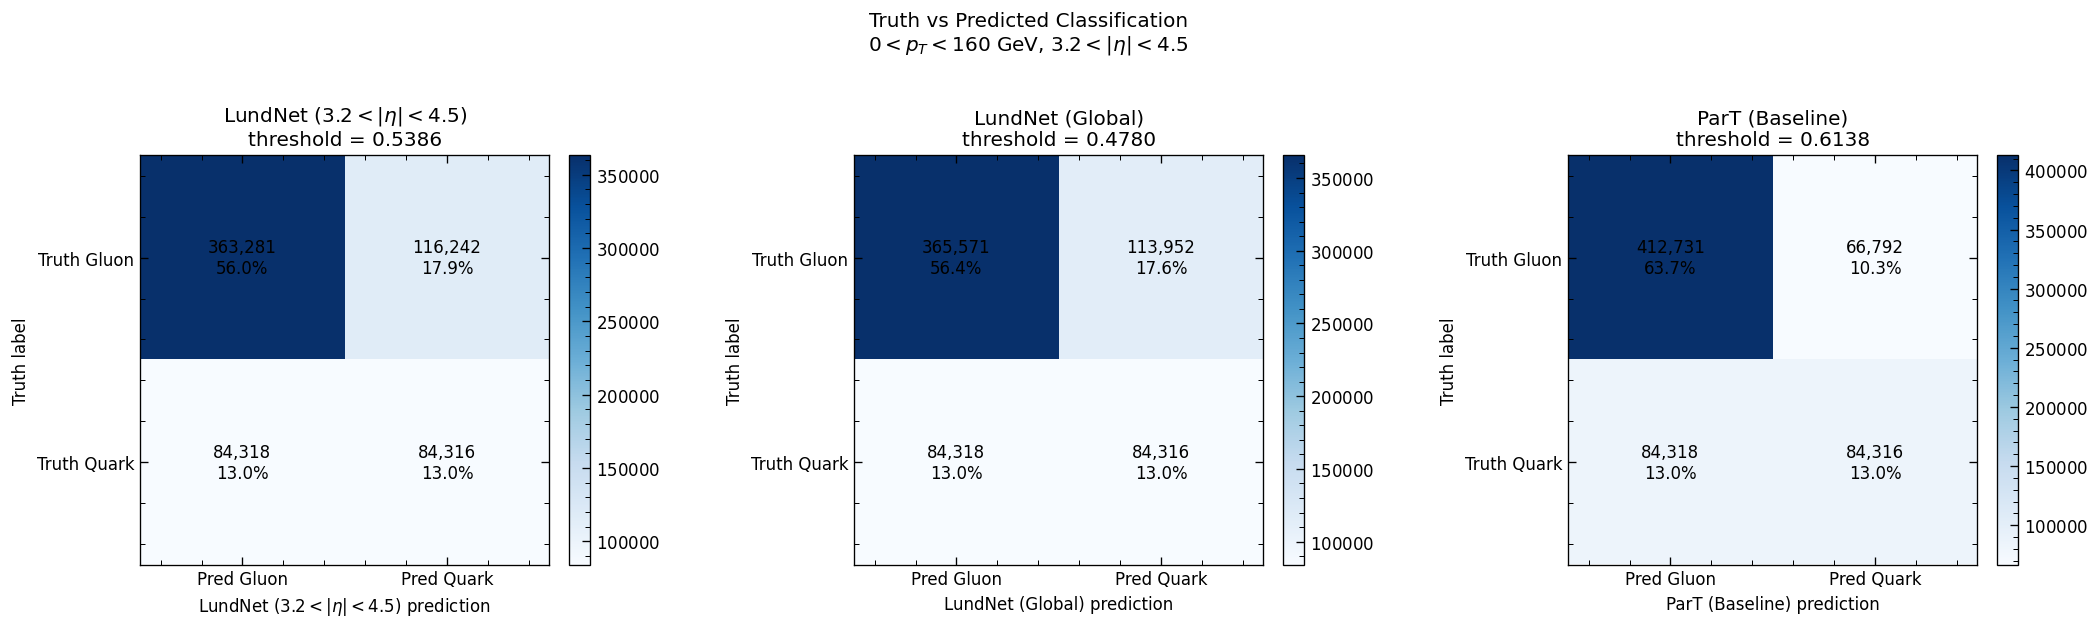

In [29]:

truth_labels = np.array(data["labels"])[mask_sel]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

for ax, model_name in zip(axes, models):
    scores    = np.array(models[model_name]["scores"])[mask_sel]
    threshold = models[model_name].get("threshold_score", 0.5)
    pred      = (scores > threshold).astype(int)

    confusion = np.zeros((2, 2), dtype=int)
    for true_l in (0, 1):
        for pred_l in (0, 1):
            confusion[true_l, pred_l] = np.sum((truth_labels == true_l) & (pred == pred_l))

    im = ax.imshow(confusion, cmap='Blues')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    total = confusion.sum()
    for i in range(2):
        for j in range(2):
            count = confusion[i, j]
            frac  = 100.0 * count / total if total > 0 else 0.0
            ax.text(j, i, f'{count:,}\n{frac:.1f}%', ha='center', va='center', color='black')

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Gluon', 'Pred Quark'])
    ax.set_yticklabels(['Truth Gluon', 'Truth Quark'])
    ax.set_xlabel(f'{nice_names.get(model_name, model_name)} prediction')
    ax.set_ylabel('Truth label')
    ax.set_title(f'{nice_names.get(model_name, model_name)}\nthreshold = {threshold:.4f}')

fig.suptitle(f'Truth vs Predicted Classification\n{_region}', y=1.03)
plt.tight_layout()
plt.show()

In [30]:
# ── Load combined scores and add combiner to models ──────────────────────────

combined_score_file = "/home/xzcqsfhu/lundtoptagger/qg_analysis_data/jet2m_ParT/scores/Combined_scoring/combiner_0_160_pt_3.2_4.5_50%train_20%test/Final_Scores_Combined_ParT_LundNet_combined_20%_test_fwd_lowpt_kTNone.root"

combined_data = uproot.concatenate(f"{combined_score_file}:{tree_name}")

print("Combined score file fields:")
from IPython.display import display
display(combined_data.fields)

Combined score file fields:


['fjet_m',
 'fjet_pt',
 'fjet_eta',
 'fjet_phi',
 'fjet_truth_label',
 'fjet_Nconst',
 'fjet_Nconst_Charged',
 'parT_score',
 'EventInfo_mcEventWeight',
 'EventInfo_mcChannelNumber',
 'labels',
 'fjet_LundNet_SRJ_eta3.2_4.5_pt0_160_50%_batch4500_lr0.0004_e18_score',
 'fjet_Combined_LundNet_ParT_eta3.2_4.5_pt0_160_e50_score']

In [31]:
# ── Add combiner entry to models and nice_names ───────────────────────────────
# Update the branch name below to match what appears in combined_data.fields

COMBINED_BRANCH = "fjet_Combined_LundNet_ParT_eta3.2_4.5_pt0_160_e50_score"  # <-- verify from Cell A output

models["Combiner (LundNet + ParT)"] = {
    "scores": combined_data[COMBINED_BRANCH]
}

nice_names["Combiner (LundNet + ParT)"] = r"Combiner (LundNet $\oplus$ ParT)"

model_colors["ParT (Baseline)"]            = "tab:green"
model_colors["LundNet 3.2-4.5 eta 0-160 pT 20%"] = "tab:blue"
model_colors["Combiner (LundNet + ParT)"]  = "tab:orange"

print("Models now:", list(models.keys()))

Models now: ['LundNet 3.2-4.5 eta 0-160 pT 20%', 'LundNet 1% (Baseline)', 'ParT (Baseline)', 'Combiner (LundNet + ParT)']


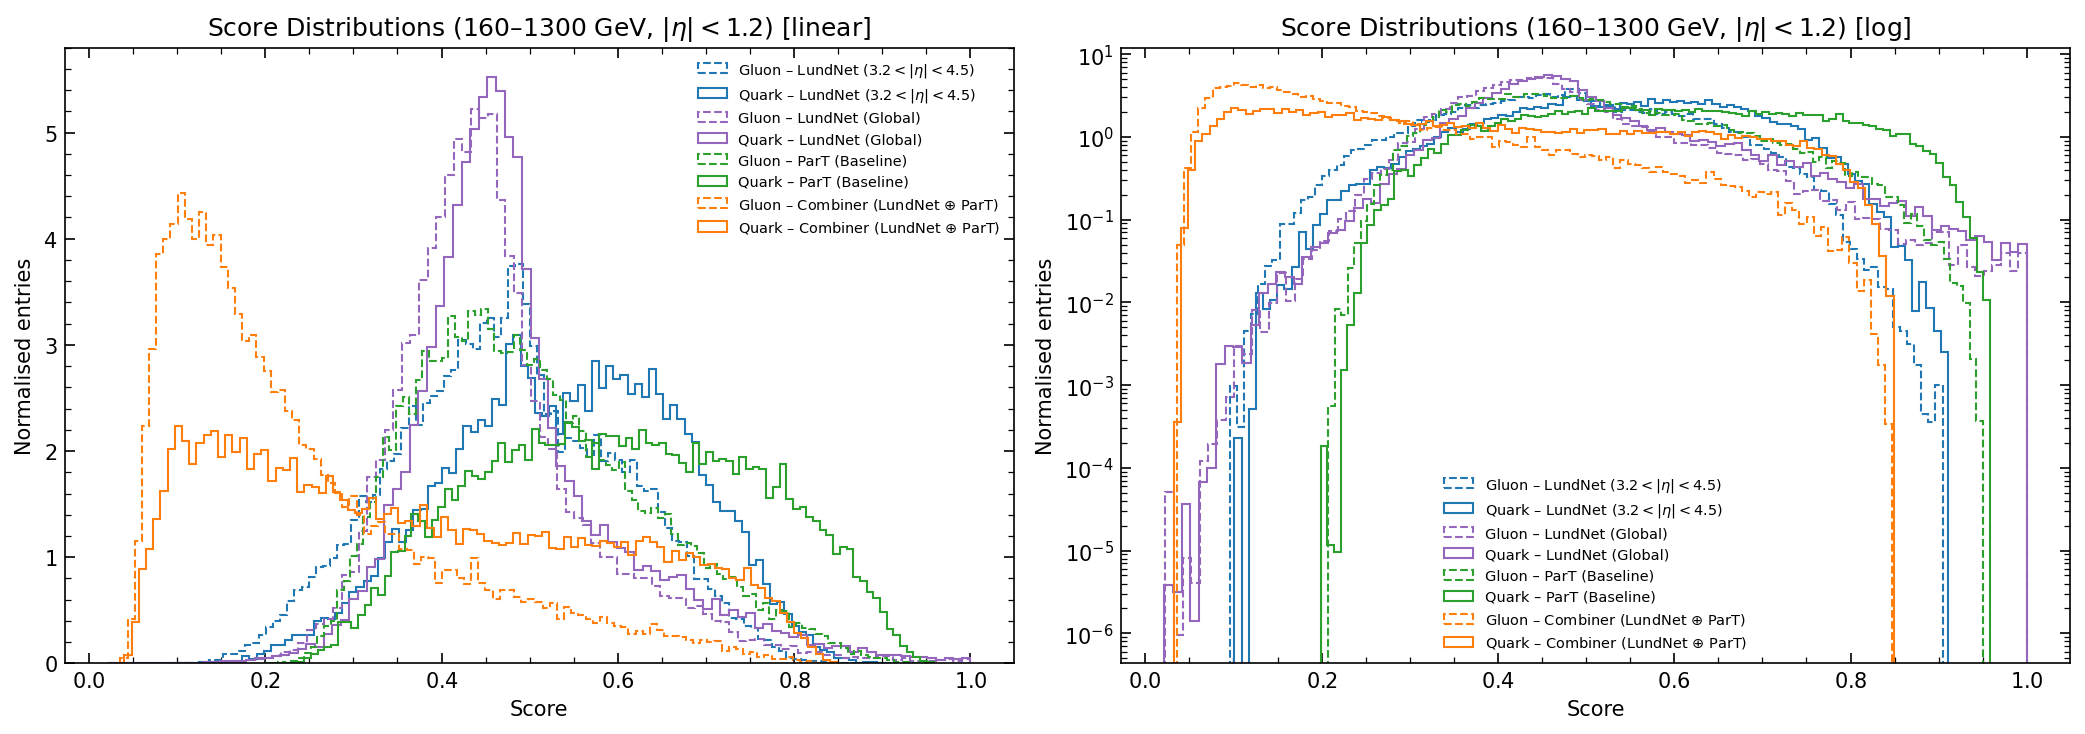

In [32]:
# ── Score distributions ───────────────────────────────────────────────────────

labels_comb = combined_data["labels"]
weights_comb = np.array([dsid_weight_map[dsid] for dsid in combined_data["EventInfo_mcChannelNumber"]]) \
               * combined_data["EventInfo_mcEventWeight"]

hist_params = dict(bins=100, density=True, histtype="step")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

for ax, yscale in zip(axes, ["linear", "log"]):
    for i, model in enumerate(models):
        scores = models[model]["scores"]
        color  = model_colors.get(model, f"C{i}")
        ax.hist(scores[labels_comb == 0], weights=weights_comb[labels_comb == 0],
                label=f"Gluon – {nice_names.get(model, model)}", ls="--", color=color, **hist_params)
        ax.hist(scores[labels_comb == 1], weights=weights_comb[labels_comb == 1],
                label=f"Quark – {nice_names.get(model, model)}", ls="-",  color=color, **hist_params)
    ax.set_yscale(yscale)
    ax.set_xlabel("Score")
    ax.set_ylabel("Normalised entries")
    ax.legend(frameon=False, fontsize="x-small")
    ax.set_title(f"Score Distributions (160–1300 GeV, $|\\eta| < 1.2$) [{yscale}]")

plt.tight_layout()
plt.show()

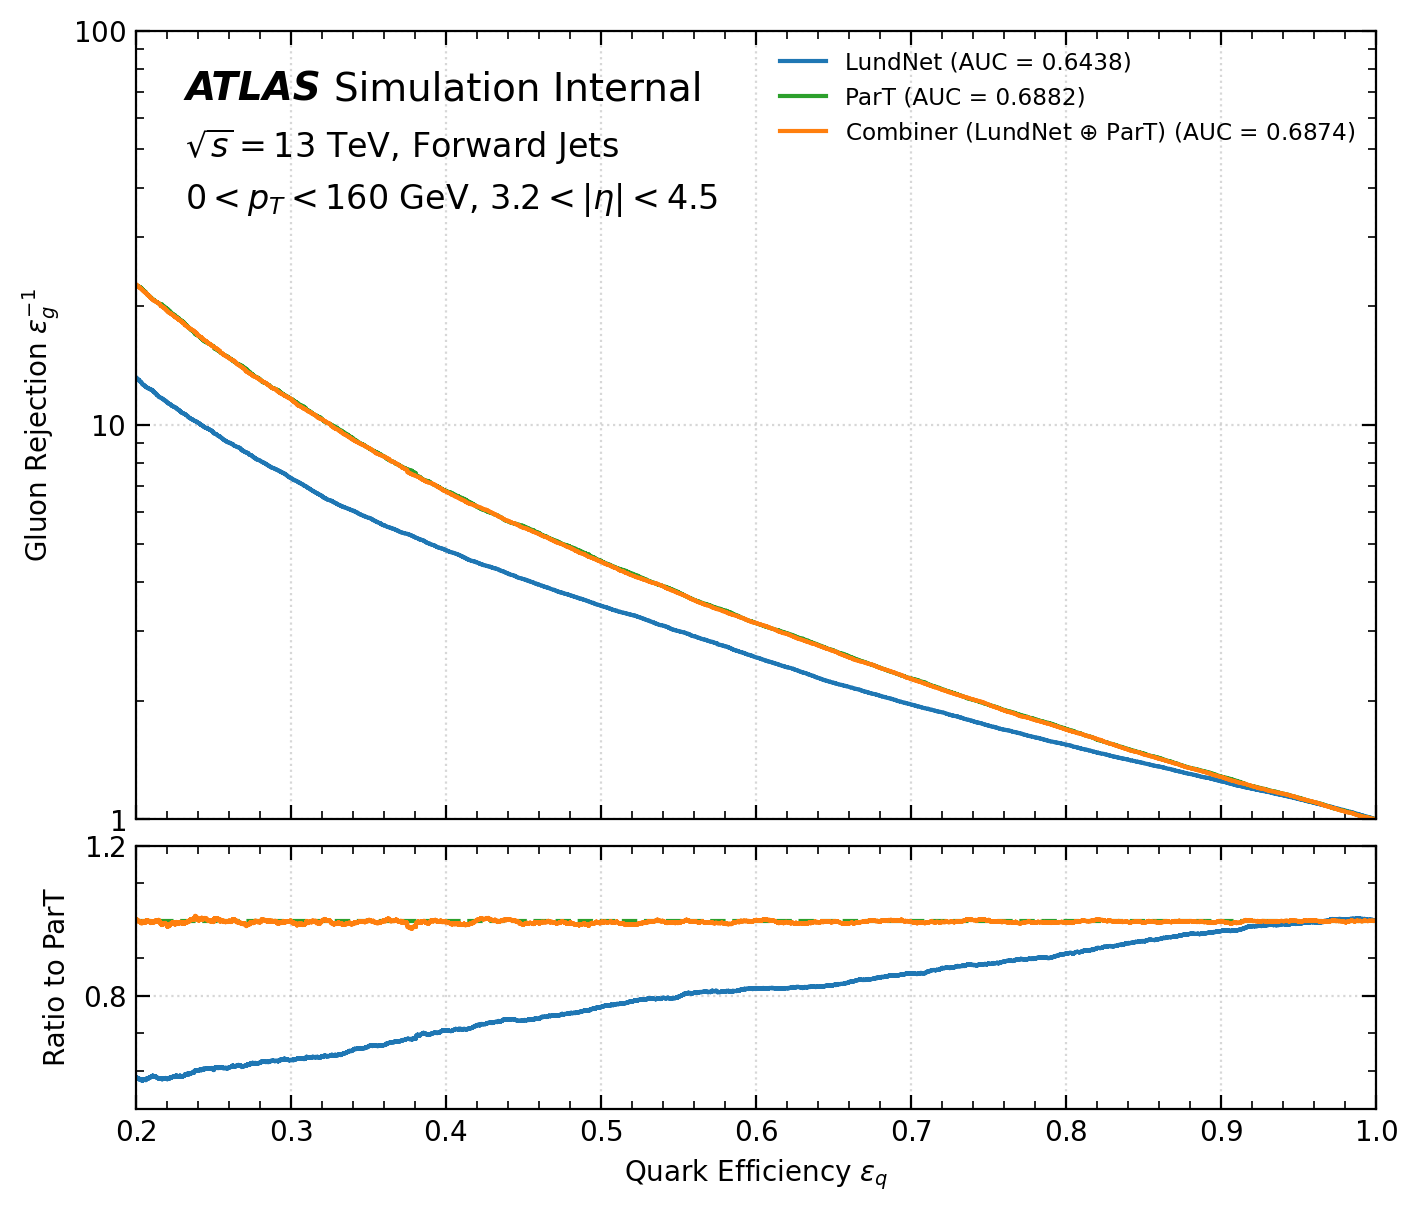

In [36]:
# ── ROC curves: ParT vs LundNet (regional) vs Combiner ───────────────────────

from matplotlib.ticker import MultipleLocator
import matplotlib.ticker

# Clean subset — drop global LundNet
models_clean = {k: v for k, v in models.items() if k != "LundNet 1% (Baseline)"}

nice_names_clean = {
    "LundNet 3.2-4.5 eta 0-160 pT 20%": r"LundNet",
    "ParT (Baseline)":                   r"ParT",
    "Combiner (LundNet + ParT)":         r"Combiner (LundNet $\oplus$ ParT)",
}

# change colour of Combiner to orange, keep others as default
model_colors = {
    "ParT (Baseline)": "tab:green",
    "LundNet 3.2-4.5 eta 0-160 pT 20%": "tab:blue",
    "Combiner (LundNet + ParT)": "tab:orange"
}

cuts_comb = (
    (combined_data["fjet_pt"]  > pt_min) & (combined_data["fjet_pt"]  < pt_max) &
    (np.abs(combined_data["fjet_eta"]) > eta_min) &
    (np.abs(combined_data["fjet_eta"]) < eta_max)
)

y_truth_comb     = np.array(labels_comb[cuts_comb])
weights_comb_cut = weights_comb[cuts_comb]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 7), dpi=200,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05},
    sharex=True
)

roc_store = {}
for i, model in enumerate(models_clean):
    scores  = np.array(models_clean[model]["scores"])[cuts_comb]
    fpr, tpr, _ = roc_curve(y_truth_comb, scores, sample_weight=weights_comb_cut)
    roc_auc = auc(fpr, tpr)
    roc_store[model] = (fpr, tpr)
    color = model_colors.get(model, f"C{i}")
    ax1.plot(tpr, 1/np.maximum(fpr, 1e-10),
             label=fr"{nice_names_clean.get(model, model)} (AUC = {roc_auc:.4f})", color=color)

ax1.set_ylabel(r"Gluon Rejection $\epsilon_g^{-1}$")
ax1.set_xlim([0.2, 1]); ax1.set_ylim([1, 100])
ax1.set_yscale("log")
ax1.set_yticks([1, 10, 100])
ax1.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax1.grid(True, which='major', ls=":", alpha=0.5)
ax1.legend(frameon=False, fontsize='small')

text_args = {"transform": ax1.transAxes, "va": "top"}
ax1.text(0.04, 0.95, "ATLAS",               fontsize=14, fontweight="bold", style="italic", **text_args)
ax1.text(0.16, 0.95, "Simulation Internal", fontsize=14, **text_args)
ax1.text(0.04, 0.88, r"$\sqrt{s} = 13$ TeV, Forward Jets", fontsize=12, **text_args)
ax1.text(0.04, 0.81, fr"${pt_min} < p_T < {pt_max}$ GeV, $3.2 < |\eta| < {eta_max}$", fontsize=12, **text_args)

ref_fpr, ref_tpr = roc_store["ParT (Baseline)"]
ref_mask = ref_fpr > 0
ref_tpr_m, ref_fpr_m = ref_tpr[ref_mask], ref_fpr[ref_mask]

for i, model in enumerate(models_clean):
    color = model_colors.get(model, f"C{i}")
    if model == "ParT (Baseline)":
        ax2.axhline(1, color=color, ls="--"); continue
    fpr, tpr = roc_store[model]
    interp_rej = np.interp(ref_tpr_m, tpr, 1/np.maximum(fpr, 1e-10), left=np.nan, right=np.nan)
    ax2.plot(ref_tpr_m, interp_rej / (1/np.maximum(ref_fpr_m, 1e-10)), color=color)

ax2.set_xlabel(r"Quark Efficiency $\epsilon_q$")
ax2.set_ylabel(f"Ratio to ParT")
ax2.set_ylim([0.5, 1.2])
ax2.xaxis.set_major_locator(MultipleLocator(0.1))
ax2.yaxis.set_major_locator(MultipleLocator(0.4))
ax2.grid(True, which='major', ls=":", alpha=0.5)

plt.show()

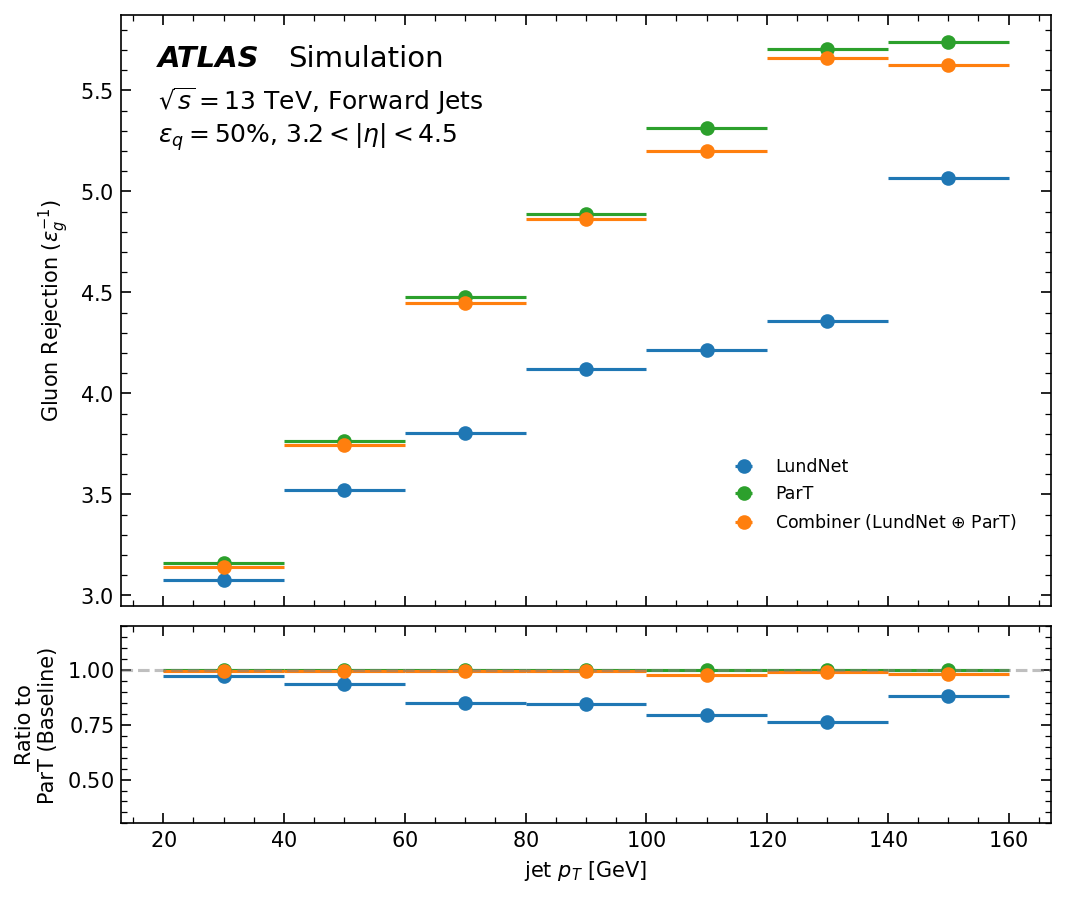

In [37]:
# ── Gluon rejection vs pT: ParT vs LundNet (regional) vs Combiner ────────────

# Patch nice_names temporarily so the function picks up the clean labels
_nice_names_backup = nice_names.copy()
nice_names.update(nice_names_clean)

# need combiner colour to be orange

def plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5, reference_model="ParT (Baseline)"):
    pt = data["fjet_pt"]
    labels = data["labels"]
    bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
    bin_half_widths = (pt_bins[1:] - pt_bins[:-1]) / 2
    
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 7), dpi=150, sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    
    model_colors = {"ParT (Baseline)": "tab:green", "LundNet 1% (Baseline)": "tab:purple", "LundNet 3.2-4.5 eta 0-160 pT 20%": "tab:blue", "Combiner (LundNet + ParT)": "tab:orange"}
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    model_rejections = {}
    
    for i, model_name in enumerate(models):
        scores = models[model_name]["scores"]
        rejections = []
        color = model_colors.get(model_name, default_colors[i % len(default_colors)])
        
        for i_bin in range(len(pt_bins)-1):
            mask = (pt >= pt_bins[i_bin]) & (pt < pt_bins[i_bin+1])
            if np.sum(mask) < 10: 
                rejections.append(np.nan); continue
            
            y_true, y_score, w = ak.to_numpy(labels[mask]), ak.to_numpy(scores[mask]), ak.to_numpy(weights[mask])
            
            # Weighted threshold calculation
            s_mask, b_mask = (y_true == 1), (y_true == 0)
            s_scores, s_w = y_score[s_mask], w[s_mask]
            
            sorter = np.argsort(s_scores)
            cum_w = np.cumsum(s_w[sorter])
            threshold = s_scores[sorter][np.searchsorted(cum_w, cum_w[-1] * (1 - signal_efficiency))]
            
            # Rejection
            eps_g = np.sum(w[b_mask & (y_score > threshold)]) / np.sum(w[b_mask])
            rejections.append(1.0 / eps_g if eps_g > 0 else np.nan)
            
        rejections = np.array(rejections)
        model_rejections[model_name] = rejections
        
        # Plot Main
        mask = ~np.isnan(rejections)
        ax0.errorbar(bin_centers[mask], rejections[mask], xerr=bin_half_widths[mask], 
                     fmt='o', label=nice_names.get(model_name, model_name), 
                     capsize=0, elinewidth=1.5, color=color)
        
    # Formatting
    ax0.set_ylabel(r"Gluon Rejection ($\epsilon_{g}^{-1}$)")
    #ax0.set_yscale("log")
    ax0.legend(
        frameon=False, 
        loc='lower right', 
        bbox_to_anchor=(0.98, 0.1), # (x, y) coordinates from 0 to 1
        fontsize='small'
    )
    
    # ATLAS Text
    text_args = {"transform": ax0.transAxes, "va": 'top'}
    ax0.text(0.04, 0.95, "ATLAS", fontsize=14, fontweight='bold', style='italic', **text_args)
    ax0.text(0.18, 0.95, "Simulation", fontsize=14, **text_args)
    ax0.text(0.04, 0.88, r"$\sqrt{s} = 13$ TeV, Forward Jets", fontsize=12, **text_args)
    ax0.text(0.04, 0.82, f"$\epsilon_q = {int(signal_efficiency*100)}\%$, $3.2 < |\eta| < {eta_max}$", fontsize=12, **text_args)

    # Ratio Logic
    if reference_model in model_rejections:
        ref_rej = model_rejections[reference_model]
        for i, model_name in enumerate(models):
            color = model_colors.get(model_name, default_colors[i % len(default_colors)])
            ratio = model_rejections[model_name] / ref_rej
            mask = ~np.isnan(ratio)
            ax1.errorbar(bin_centers[mask], ratio[mask], xerr=bin_half_widths[mask], 
                         fmt='o', capsize=0, elinewidth=1.5, color=color)
    
    ax1.axhline(1, color='gray', linestyle='--', alpha=0.5)
    ax1.set_ylabel(f"Ratio to\nParT (Baseline)", fontsize=10)
    ax1.set_xlabel(r"jet $p_T$ [GeV]")
    ax1.set_ylim(0.3, 1.2)
    plt.show()


pt_bins = np.linspace(20, 160, 8)

plot_gluon_rejection_vs_pt(
    models_clean,
    combined_data,
    weights_comb,
    pt_bins,
    signal_efficiency=0.5,
    reference_model="ParT (Baseline)"
)

# Restore original nice_names so earlier cells are unaffected
nice_names.clear()
nice_names.update(_nice_names_backup)

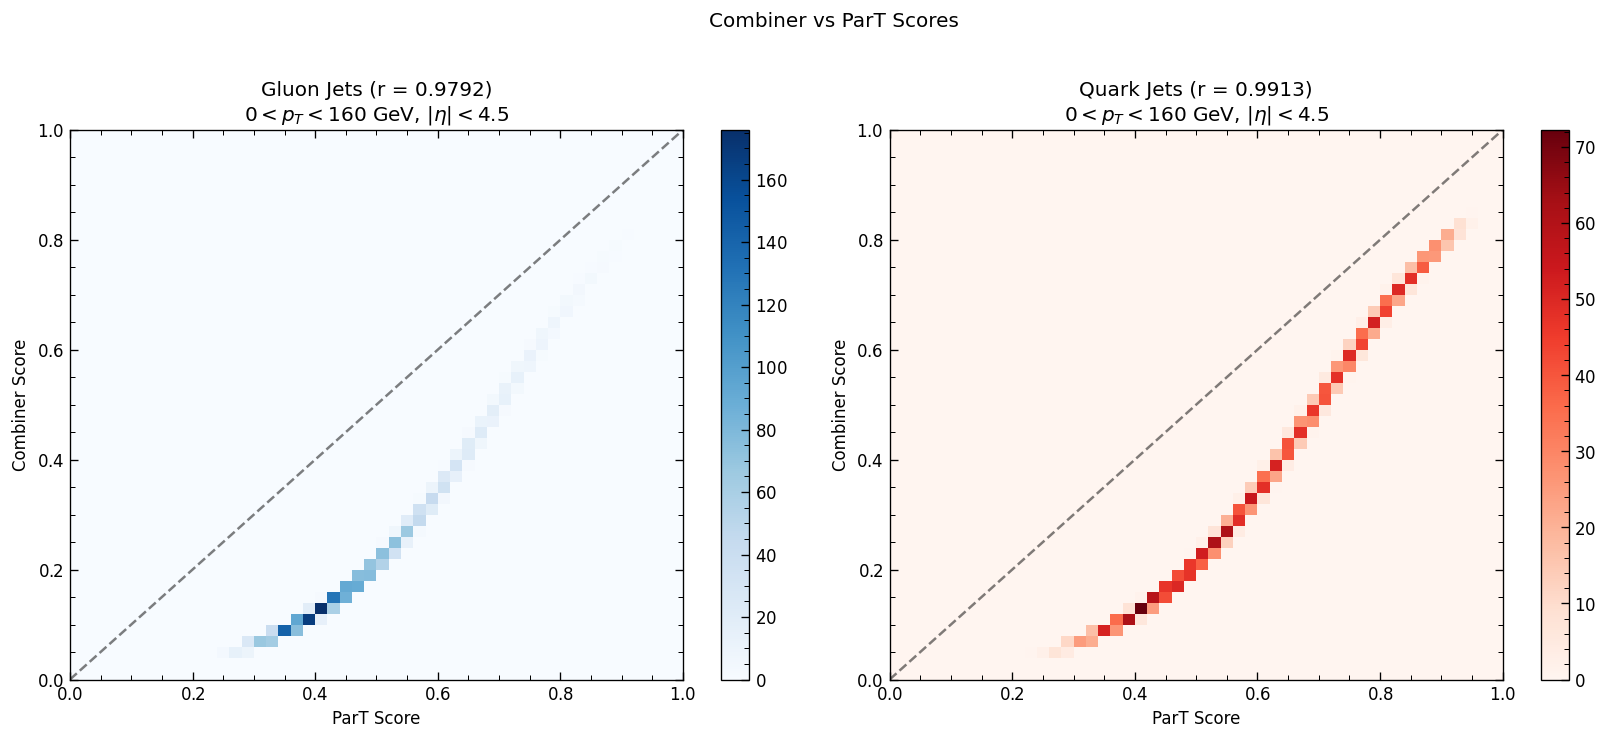

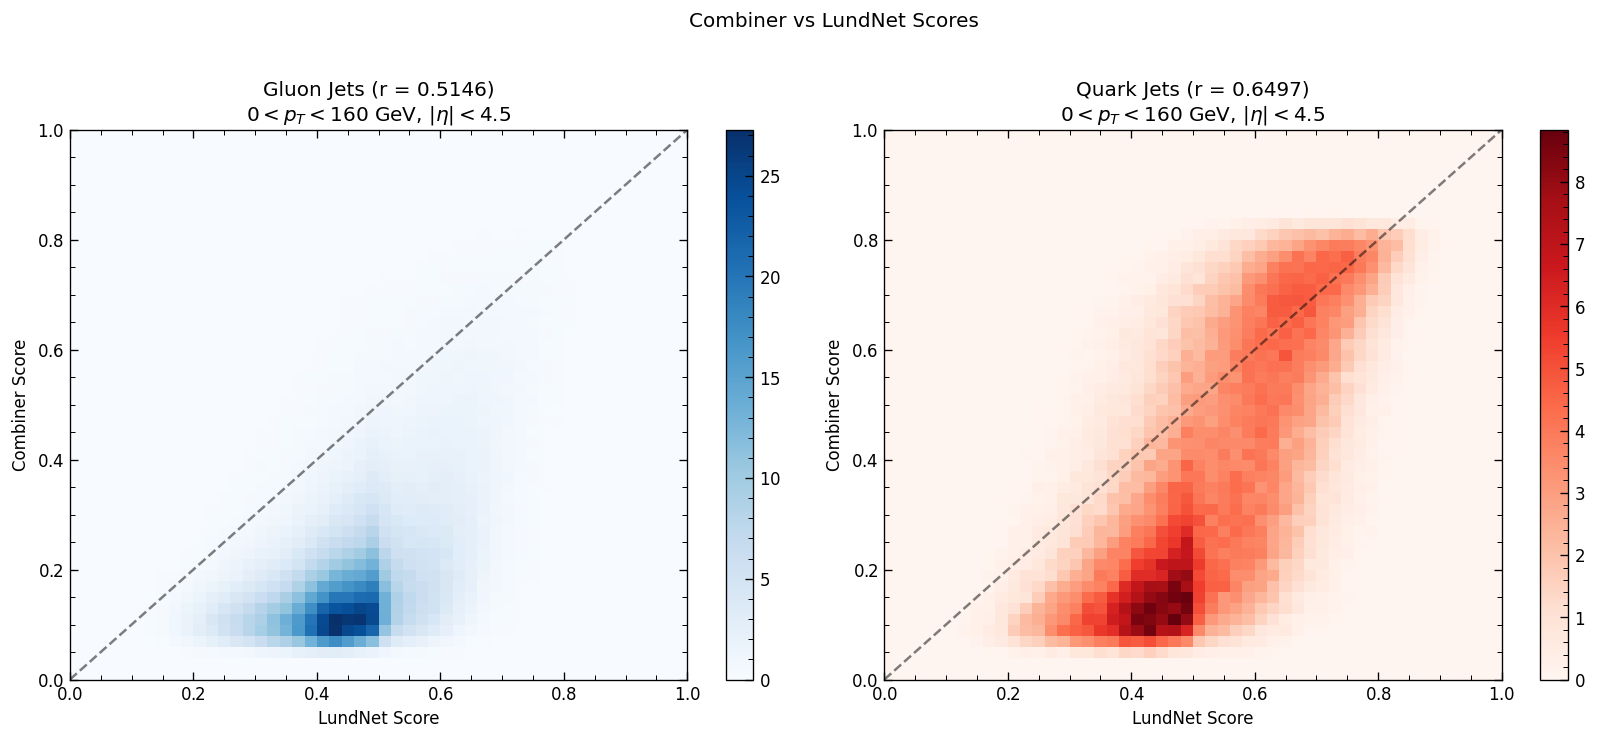

In [38]:
# ── Combiner score vs LundNet and ParT: correlation + 2D density ──────────────

comb_scores  = np.array(models["Combiner (LundNet + ParT)"]["scores"])[cuts_comb]
part_scores_c = np.array(models["ParT (Baseline)"]["scores"])[cuts_comb]
lund_scores_c = np.array(models["LundNet 3.2-4.5 eta 0-160 pT 20%"]["scores"])[cuts_comb]
labs_c        = y_truth_comb

q_mask_c = (labs_c == 1)
g_mask_c = (labs_c == 0)

_region_c = fr"${pt_min} < p_T < {pt_max}$ GeV, $|\eta| < {eta_max}$"

for comp_scores, comp_name in [(part_scores_c, "ParT"), (lund_scores_c, "LundNet")]:
    corr_q = np.corrcoef(comp_scores[q_mask_c], comb_scores[q_mask_c])[0, 1]
    corr_g = np.corrcoef(comp_scores[g_mask_c], comb_scores[g_mask_c])[0, 1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=120)
    h1 = ax1.hist2d(comp_scores[g_mask_c], comb_scores[g_mask_c],
                    bins=50, cmap='Blues', density=True, range=[[0,1],[0,1]])
    ax1.set_title(f'Gluon Jets (r = {corr_g:.4f})\n{_region_c}')
    ax1.set_xlabel(f'{comp_name} Score'); ax1.set_ylabel('Combiner Score')
    plt.colorbar(h1[3], ax=ax1); ax1.plot([0,1],[0,1],'k--',alpha=0.5)

    h2 = ax2.hist2d(comp_scores[q_mask_c], comb_scores[q_mask_c],
                    bins=50, cmap='Reds', density=True, range=[[0,1],[0,1]])
    ax2.set_title(f'Quark Jets (r = {corr_q:.4f})\n{_region_c}')
    ax2.set_xlabel(f'{comp_name} Score'); ax2.set_ylabel('Combiner Score')
    plt.colorbar(h2[3], ax=ax2); ax2.plot([0,1],[0,1],'k--',alpha=0.5)

    plt.suptitle(f'Combiner vs {comp_name} Scores', y=1.02)
    plt.tight_layout(); plt.show()